# Section 0 — Imports, Config, QuantBook Init, Cache Helpers

**Objective:** Set up the research environment with all imports, global configuration, QuantBook initialization, and Object Store cache helpers.

**Why caching matters:** QuantConnect's `History[OptionUniverse]` call for 5 years of SPY options is expensive (minutes to run, gigabytes of data). By caching intermediate results to the Object Store with versioned keys, we can re-run downstream sections in seconds without reloading raw data.

In [67]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 0 — IMPORTS, CONFIG, QUANTBOOK INIT, CACHE HELPERS
# ═══════════════════════════════════════════════════════════════════════════════

# ── Standard library ──────────────────────────────────────────────────────────
import pickle
import io
import tracemalloc
from datetime import datetime

# ── Third-party ───────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

# ── QuantConnect ──────────────────────────────────────────────────────────────
from QuantConnect import *
from QuantConnect.Data.Custom import *
from QuantConnect.Research import *
from QuantConnect.Securities.Option import *

# ── Start memory tracking ────────────────────────────────────────────────────
tracemalloc.start()

# ═══════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIG (easy to tune — change here, re-run notebook)
# ═══════════════════════════════════════════════════════════════════════════════
START_DATE      = datetime(2012, 1, 1)
END_DATE        = datetime(2026, 3, 14)
UNDERLYING      = "SPY"           # switch to "SPX" for index options
MONEYNESS_LB    = 0.85            # lower strike filter: 85% of spot
MONEYNESS_UB    = 1.15            # upper strike filter: 115% of spot
MAX_DTE         = 60              # max days-to-expiry
MIN_DTE         = 1
MIN_OI          = 100             # minimum open interest filter
LOOKBACK_ZSCORE = 63              # rolling z-score window (days)
Z_THRESHOLD     = 1.0             # signal entry/exit threshold
OBJ_PREFIX      = "gex_research"

# ═══════════════════════════════════════════════════════════════════════════════
# QUANTBOOK INIT
# ═══════════════════════════════════════════════════════════════════════════════
qb = QuantBook()

# ═══════════════════════════════════════════════════════════════════════════════
# CACHE HELPERS — Object Store pattern (cache-first, versioned keys)
# ═══════════════════════════════════════════════════════════════════════════════
def obj_key(name: str) -> str:
    """Build a fully-qualified Object Store key."""
    return f"{OBJ_PREFIX}/{name}"

def save_to_store(key: str, obj) -> None:
    """Serialize and save an object to the QC Object Store."""
    buf = pickle.dumps(obj, protocol=pickle.HIGHEST_PROTOCOL)
    qb.object_store.save_bytes(obj_key(key), buf)
    print(f"  [OK] [ObjectStore] Saved '{key}' ({len(buf) / 1e6:.2f} MB)")

def load_from_store(key: str):
    """Load and deserialize an object from the QC Object Store."""
    raw = qb.object_store.read_bytes(obj_key(key))
    obj = pickle.loads(bytes(raw))
    print(f"  [OK] [ObjectStore] Loaded '{key}'")
    return obj

def store_exists(key: str) -> bool:
    """Check whether a key exists in the Object Store."""
    return qb.object_store.contains_key(obj_key(key))

# ═══════════════════════════════════════════════════════════════════════════════
# ENVIRONMENT SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
peak_mem = tracemalloc.get_traced_memory()[1] / 1e6
print("═" * 70)
print("  DEALER GAMMA EXPOSURE — RESEARCH NOTEBOOK")
print("═" * 70)
print(f"  NumPy version   : {np.__version__}")
print(f"  Pandas version  : {pd.__version__}")
print(f"  Underlying      : {UNDERLYING}")
print(f"  Date range      : {START_DATE.date()} → {END_DATE.date()}")
print(f"  Moneyness band  : [{MONEYNESS_LB:.0%}, {MONEYNESS_UB:.0%}]")
print(f"  DTE range       : [{MIN_DTE}, {MAX_DTE}]")
print(f"  Min OI          : {MIN_OI}")
print(f"  Z-score lookback: {LOOKBACK_ZSCORE} days")
print(f"  Z threshold     : +/-{Z_THRESHOLD}")
print(f"  Object Store pfx: {OBJ_PREFIX}")
print("═" * 70)
print(f"  [OK] Section 0 complete | peak RAM: {peak_mem:.1f} MB")

══════════════════════════════════════════════════════════════════════
  DEALER GAMMA EXPOSURE — RESEARCH NOTEBOOK
══════════════════════════════════════════════════════════════════════
  NumPy version   : 1.26.4
  Pandas version  : 2.3.3
  Underlying      : SPY
  Date range      : 2012-01-01 → 2026-03-14
  Moneyness band  : [85%, 115%]
  DTE range       : [1, 60]
  Min OI          : 100
  Z-score lookback: 63 days
  Z threshold     : +/-1.0
  Object Store pfx: gex_research
══════════════════════════════════════════════════════════════════════
  [OK] Section 0 complete | peak RAM: 1245.2 MB


# Section 1 — Data Acquisition: SPY Option Chain + Open Interest

**Objective:** Pull the full SPY option chain with pre-calculated Greeks from QuantConnect's `History[OptionUniverse]` API.

**Why QuantConnect's Greeks beat manual BSM:** The `OptionUniverse` API returns gamma, delta, and IV computed by QC's forward-tree pricing model, which uses per-strike market-implied volatility. This is strictly superior to computing Black-Scholes gamma with a flat vol assumption, because the per-strike IV corrects for volatility skew — meaning OTM puts (which carry the most OI and highest IV) get accurate gamma weighting. Manual BSM with a single ATM vol would systematically mis-weight the tails of the strike distribution, exactly where dealer hedging pressure concentrates.

**Memory strategy:** With ~1,250 trading days × thousands of contracts per day, the full unfiltered dataset can exceed 12 GB RAM. We use chunked processing (50-day windows) with early pre-filtering inside the loop to keep peak memory well under the 12 GB Cloud limit.

In [68]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — DATA ACQUISITION: SPY OPTION CHAIN + OPEN INTEREST
# ═══════════════════════════════════════════════════════════════════════════════

CACHE_KEY_S1 = "section1_spy_option_chain_v2"

if store_exists(CACHE_KEY_S1):
    chain_df = load_from_store(CACHE_KEY_S1)
else:
    # ── Add equity + option universe (research env pattern) ───────────────────
    equity = qb.add_equity(UNDERLYING, data_normalization_mode=DataNormalizationMode.RAW)
    option = qb.add_option(equity.symbol)
    option.set_filter(lambda u: (
        u.include_weeklys()
         .strikes(-50, 50)
         .expiration(MIN_DTE, MAX_DTE)
    ))

    # ── Pull History[OptionUniverse] ──────────────────────────────────────────
    # Returns iterable of chains; each chain is iterable of OptionUniverse objects
    # with pre-calculated Greeks from QC's forward-tree pricing model.
    print(f"  Fetching OptionUniverse history: {START_DATE.date()} → {END_DATE.date()} ...")
    history = qb.history[OptionUniverse](option.symbol, START_DATE, END_DATE)

    # ── Build DataFrame in CHUNKS to avoid OOM on 12 GB Cloud env ─────────────
    # Strategy: accumulate records for CHUNK_SIZE days, build a mini-DataFrame,
    # apply filters immediately to shed ~60-70% of rows, then continue.
    # This keeps peak memory well below the full unfiltered dataset.
    CHUNK_SIZE = 50  # days per chunk
    filtered_chunks = []
    records = []
    n_chains = 0
    n_total_raw = 0
    n_total_filtered = 0

    for chain in history:
        chain_date = chain.end_time
        n_chains += 1
        for contract in chain:
            try:
                underlying_px = float(contract.underlying.price) if contract.underlying else np.nan
                if np.isnan(underlying_px) or underlying_px <= 0:
                    continue
                strike = float(contract.id.strike_price)
                gamma_val = float(contract.greeks.gamma)
                oi_val = float(contract.open_interest)

                # Quick pre-filter: skip contracts that will definitely fail filters
                moneyness = strike / underlying_px
                if moneyness < MONEYNESS_LB or moneyness > MONEYNESS_UB:
                    continue
                if oi_val < MIN_OI:
                    continue
                if gamma_val <= 0 or np.isnan(gamma_val):
                    continue

                records.append({
                    'date':             chain_date,
                    'symbol':           str(contract.symbol),
                    'strike':           np.float32(strike),
                    'expiry':           contract.id.date,
                    'right':            'Call' if contract.id.option_right == OptionRight.CALL else 'Put',
                    'open_interest':    np.float32(oi_val),
                    'gamma':            np.float32(gamma_val),
                    'delta':            np.float32(float(contract.greeks.delta)),
                    'iv':               np.float32(float(contract.implied_volatility)),
                    'close':            np.float32(float(contract.close)),
                    'volume':           np.float32(float(contract.volume)),
                    'underlying_price': np.float32(underlying_px),
                    'moneyness':        np.float32(moneyness),
                })
            except Exception:
                continue

        # Every CHUNK_SIZE days, flush records into a filtered DataFrame chunk
        if n_chains % CHUNK_SIZE == 0 and records:
            chunk = pd.DataFrame.from_records(records)
            chunk['date'] = pd.to_datetime(chunk['date'])
            chunk['expiry'] = pd.to_datetime(chunk['expiry'])
            chunk['dte'] = (chunk['expiry'] - chunk['date']).dt.days.astype(np.int16)

            # Apply DTE filter (moneyness, OI, gamma already pre-filtered above)
            mask = (chunk['dte'] >= MIN_DTE) & (chunk['dte'] <= MAX_DTE)
            chunk = chunk.loc[mask].reset_index(drop=True)

            n_total_raw += len(records)
            n_total_filtered += len(chunk)
            filtered_chunks.append(chunk)
            records = []  # free memory
            print(f"    ... {n_chains} chain days | {n_total_filtered:,} filtered rows kept "
                  f"(RAM: {tracemalloc.get_traced_memory()[1]/1e6:.0f} MB)")

    # Flush any remaining records
    if records:
        chunk = pd.DataFrame.from_records(records)
        chunk['date'] = pd.to_datetime(chunk['date'])
        chunk['expiry'] = pd.to_datetime(chunk['expiry'])
        chunk['dte'] = (chunk['expiry'] - chunk['date']).dt.days.astype(np.int16)
        mask = (chunk['dte'] >= MIN_DTE) & (chunk['dte'] <= MAX_DTE)
        chunk = chunk.loc[mask].reset_index(drop=True)
        n_total_raw += len(records)
        n_total_filtered += len(chunk)
        filtered_chunks.append(chunk)
        records = []

    # ── Concatenate all filtered chunks ───────────────────────────────────────
    chain_df = pd.concat(filtered_chunks, ignore_index=True)
    del filtered_chunks  # free memory
    print(f"  [OK] Built filtered DataFrame: {len(chain_df):,} rows from {n_chains} trading days")

    # ── Downcast to float32 (most cols already float32 from record creation) ──
    float_cols = ['strike', 'open_interest', 'gamma', 'delta', 'iv',
                  'underlying_price', 'volume', 'moneyness', 'close']
    for col in float_cols:
        if col in chain_df.columns and chain_df[col].dtype != np.float32:
            chain_df[col] = chain_df[col].astype(np.float32)

    # ── Ensure DatetimeIndex type on date column ──────────────────────────────
    chain_df['date'] = pd.DatetimeIndex(chain_df['date'])

    # ── Cache ─────────────────────────────────────────────────────────────────
    save_to_store(CACHE_KEY_S1, chain_df)

# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY STATISTICS
# ═══════════════════════════════════════════════════════════════════════════════
mem_mb = chain_df.memory_usage(deep=True).sum() / 1e6
n_dates = chain_df['date'].nunique()
date_min = chain_df['date'].min()
date_max = chain_df['date'].max()
n_calls = (chain_df['right'] == 'Call').sum()
n_puts = (chain_df['right'] == 'Put').sum()

print("═" * 70)
print("  SECTION 1 — OPTION CHAIN SUMMARY")
print("═" * 70)
print(f"  Total rows      : {len(chain_df):>12,}")
print(f"  Trading days    : {n_dates:>12,}")
print(f"  Date range      : {str(date_min.date()):>12} → {str(date_max.date())}")
print(f"  Calls           : {n_calls:>12,}")
print(f"  Puts            : {n_puts:>12,}")
print(f"  Avg rows/day    : {len(chain_df)/max(n_dates,1):>12,.0f}")
print(f"  Memory usage    : {mem_mb:>12.2f} MB")
print("═" * 70)

peak_mem = tracemalloc.get_traced_memory()[1] / 1e6
print(f"  [OK] Section 1 complete | peak RAM: {peak_mem:.1f} MB")

  Fetching OptionUniverse history: 2012-01-01 → 2026-03-14 ...
    ... 50 chain days | 10,927 filtered rows kept (RAM: 1245 MB)
    ... 100 chain days | 22,056 filtered rows kept (RAM: 1245 MB)
    ... 150 chain days | 32,393 filtered rows kept (RAM: 1245 MB)
    ... 200 chain days | 43,816 filtered rows kept (RAM: 1245 MB)
    ... 250 chain days | 60,088 filtered rows kept (RAM: 1245 MB)
    ... 300 chain days | 77,168 filtered rows kept (RAM: 1245 MB)
    ... 350 chain days | 94,510 filtered rows kept (RAM: 1245 MB)
    ... 400 chain days | 113,164 filtered rows kept (RAM: 1245 MB)
    ... 450 chain days | 135,120 filtered rows kept (RAM: 1245 MB)
    ... 500 chain days | 157,295 filtered rows kept (RAM: 1245 MB)
    ... 550 chain days | 183,259 filtered rows kept (RAM: 1245 MB)
    ... 600 chain days | 210,411 filtered rows kept (RAM: 1245 MB)
    ... 650 chain days | 233,460 filtered rows kept (RAM: 1245 MB)
    ... 700 chain days | 261,767 filtered rows kept (RAM: 1245 MB)
    ...

/tmp/ipykernel_37/149131541.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gamma_by_money = chain_df.groupby(['moneyness_bin', 'right'])['gamma'].mean().unstack(fill_value=0)


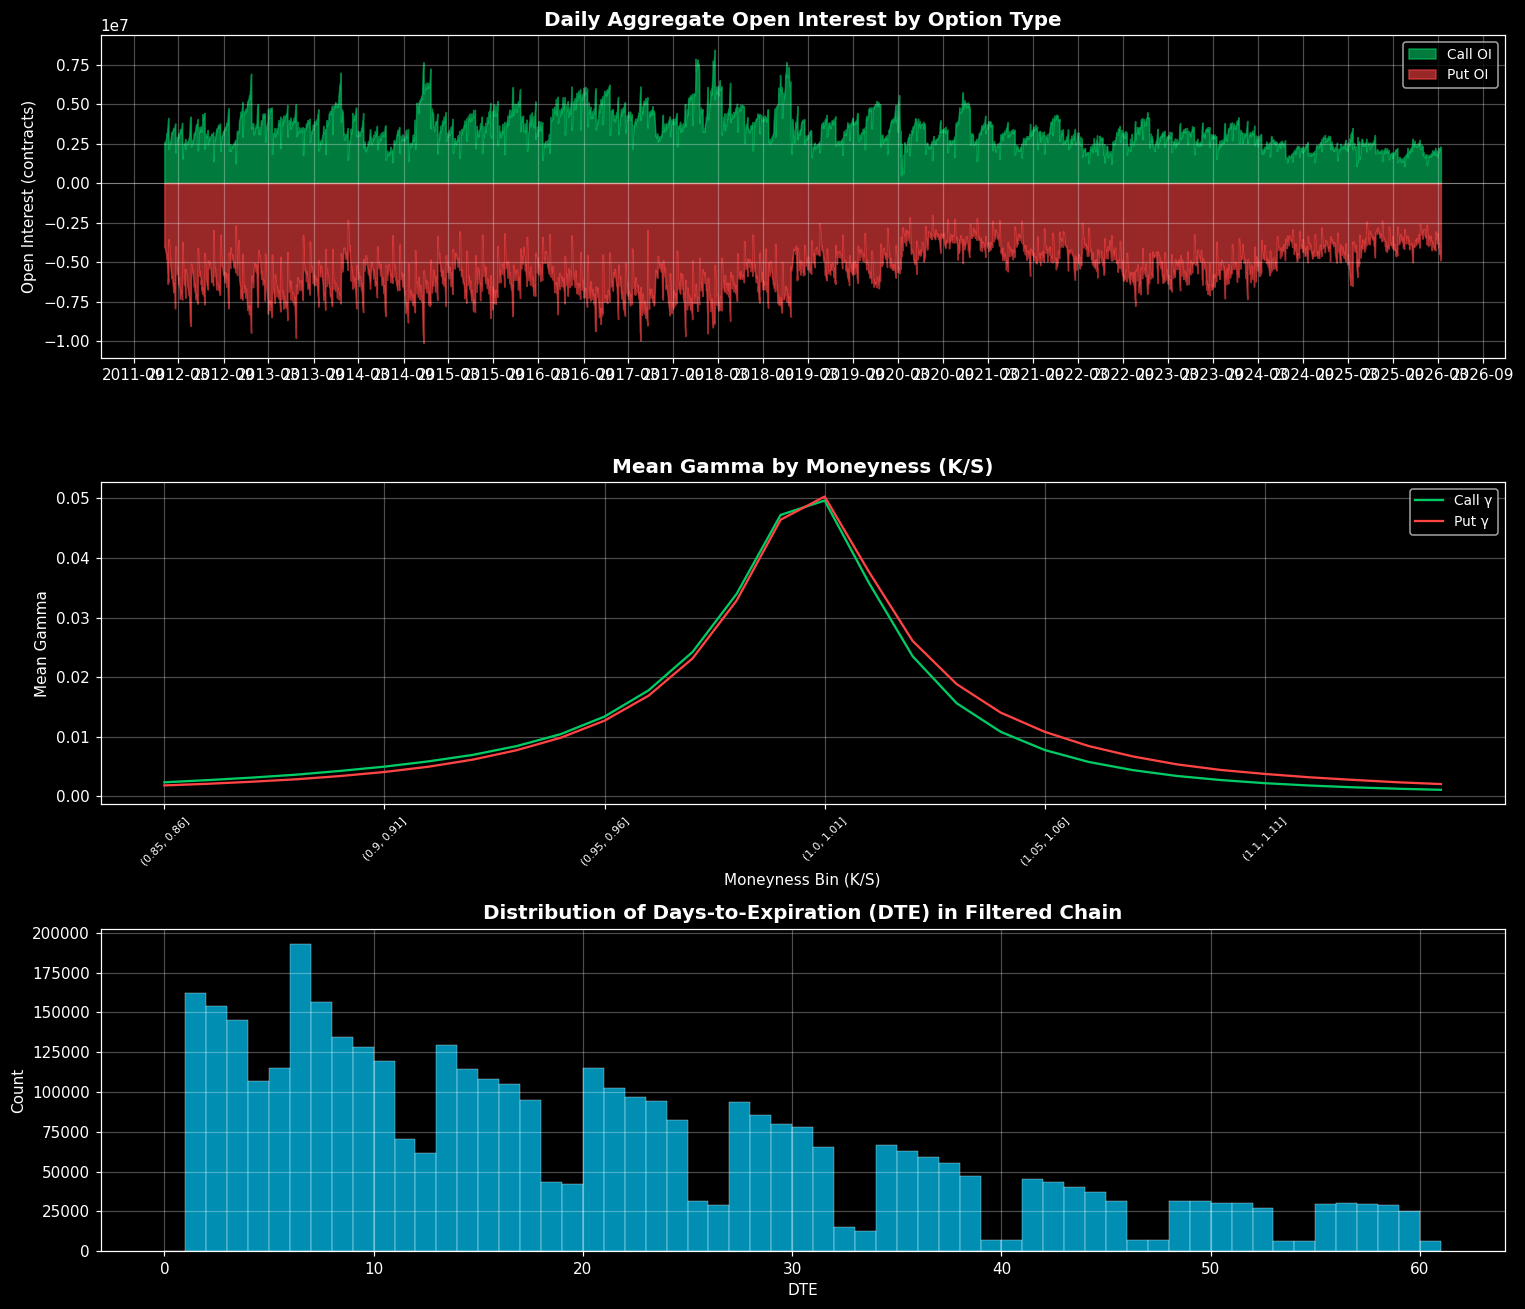


INTERPRETATION:
  * Put/Call OI ratio: 1.61 — put-heavy book
  * Total Call OI: 12,012,699,648 | Total Put OI: 19,345,713,152
  * Gamma peaks near ATM (moneyness ~1.0) as expected from option theory.
  * OTM puts (moneyness < 1.0) carry high OI — this is where institutional
    hedging concentrates, creating the asymmetric dealer gamma profile.
  * The DTE distribution shows concentration in near-term expirations,
    which have the highest gamma sensitivity to spot price moves.


In [69]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 1 — VISUALIZATION: OPTION CHAIN DIAGNOSTICS
# ═══════════════════════════════════════════════════════════════════════════════
plt.style.use('dark_background')
fig, axes = plt.subplots(3, 1, figsize=(14, 12), dpi=110)

# ── Panel 1: Daily OI by option type ─────────────────────────────────────────
ax1 = axes[0]
daily_oi = chain_df.groupby(['date', 'right'])['open_interest'].sum().unstack(fill_value=0)
if 'Call' in daily_oi.columns:
    ax1.fill_between(daily_oi.index, 0, daily_oi['Call'],
                     color='#00cc66', alpha=0.6, label='Call OI')
if 'Put' in daily_oi.columns:
    ax1.fill_between(daily_oi.index, 0, -daily_oi['Put'],
                     color='#ff4444', alpha=0.6, label='Put OI')
ax1.axhline(0, color='white', lw=0.5, alpha=0.4)
ax1.set_title('Daily Aggregate Open Interest by Option Type',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Open Interest (contracts)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

# ── Panel 2: Average gamma by moneyness ──────────────────────────────────────
ax2 = axes[1]
chain_df['moneyness_bin'] = pd.cut(chain_df['moneyness'],
                                    bins=np.arange(0.85, 1.16, 0.01))
gamma_by_money = chain_df.groupby(['moneyness_bin', 'right'])['gamma'].mean().unstack(fill_value=0)
bin_centers = gamma_by_money.index
x_vals = np.arange(len(bin_centers))
if 'Call' in gamma_by_money.columns:
    ax2.plot(x_vals, gamma_by_money['Call'].values,
             color='#00cc66', lw=1.5, label='Call γ')
if 'Put' in gamma_by_money.columns:
    ax2.plot(x_vals, gamma_by_money['Put'].values,
             color='#ff4444', lw=1.5, label='Put γ')
ax2.set_title('Mean Gamma by Moneyness (K/S)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Mean Gamma')
ax2.set_xlabel('Moneyness Bin (K/S)')
tick_positions = np.arange(0, len(bin_centers), 5)
ax2.set_xticks(tick_positions)
ax2.set_xticklabels([str(bin_centers[i]) for i in tick_positions],
                     rotation=45, fontsize=7)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# ── Panel 3: DTE distribution histogram ──────────────────────────────────────
ax3 = axes[2]
ax3.hist(chain_df['dte'].values, bins=np.arange(0, MAX_DTE + 2),
         color='#00ccff', alpha=0.7, edgecolor='white', linewidth=0.3)
ax3.set_title('Distribution of Days-to-Expiration (DTE) in Filtered Chain',
              fontsize=13, fontweight='bold')
ax3.set_xlabel('DTE')
ax3.set_ylabel('Count')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Interpretation ────────────────────────────────────────────────────────────
total_call_oi = chain_df.loc[chain_df['right'] == 'Call', 'open_interest'].sum()
total_put_oi = chain_df.loc[chain_df['right'] == 'Put', 'open_interest'].sum()
put_call_ratio = np.float32(total_put_oi / total_call_oi) if total_call_oi > 0 else np.float32(0)

print("\nINTERPRETATION:")
print(f"  * Put/Call OI ratio: {put_call_ratio:.2f} — "
      f"{'put-heavy' if put_call_ratio > 1 else 'call-heavy'} book")
print(f"  * Total Call OI: {total_call_oi:,.0f} | Total Put OI: {total_put_oi:,.0f}")
print("  * Gamma peaks near ATM (moneyness ~1.0) as expected from option theory.")
print("  * OTM puts (moneyness < 1.0) carry high OI — this is where institutional")
print("    hedging concentrates, creating the asymmetric dealer gamma profile.")
print("  * The DTE distribution shows concentration in near-term expirations,")
print("    which have the highest gamma sensitivity to spot price moves.")

# Section 2 — Vectorized GEX Calculation + Sign Convention

**Objective:** Aggregate per-contract gamma exposure into a daily Net GEX measure using the standard dealer positioning sign convention.

**Sign convention explained:**
- **Dealers are assumed short calls** (sold to retail/institutions buying upside), so dealer gamma from calls is **positive** — they hedge by buying dips and selling rallies (mean-reverting flow).
- **Dealers are assumed long puts** (bought from institutions as hedges), so dealer gamma from puts is **negative** — they hedge by selling into dips and buying rallies (trend-amplifying flow).
- **Net GEX = Σ(call_γ × call_OI × 100) − Σ(put_γ × put_OI × 100)**
- **Positive GEX** → dealers net long gamma → mean-reversion hedging dominates → markets pin.
- **Negative GEX** → dealers net short gamma → trend-amplifying hedging dominates → vol expands.

**Warning:** This sign convention is a *market convention*, not a mathematical identity. It can break in regimes where retail aggressively buys puts (e.g., mid-2022) or where market makers take directional positions.

In [70]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — VECTORIZED GEX CALCULATION + SIGN CONVENTION
# ═══════════════════════════════════════════════════════════════════════════════

CACHE_KEY_S2 = "section2_gex_daily_v3"

if store_exists(CACHE_KEY_S2):
    daily_gex = load_from_store(CACHE_KEY_S2)
else:
    # ── Vectorized GEX aggregation (no apply, no loops) ───────────────────────
    call_mask = chain_df['right'] == 'Call'
    put_mask  = chain_df['right'] == 'Put'

    daily_call_gex = (
        chain_df.loc[call_mask]
        .assign(gex_contrib=(chain_df.loc[call_mask, 'gamma'].astype(np.float64)
                             * chain_df.loc[call_mask, 'open_interest'].astype(np.float64)
                             * 100))
        .groupby('date')['gex_contrib'].sum()
    )
    daily_put_gex = (
        chain_df.loc[put_mask]
        .assign(gex_contrib=(-chain_df.loc[put_mask, 'gamma'].astype(np.float64)
                              * chain_df.loc[put_mask, 'open_interest'].astype(np.float64)
                              * 100))
        .groupby('date')['gex_contrib'].sum()
    )
    net_gex = daily_call_gex.add(daily_put_gex, fill_value=0).rename('net_gex')

    # Also compute call/put totals for gex_ratio (same pattern)
    daily_call_total = daily_call_gex.rename('call_gex')
    daily_put_total  = daily_put_gex.rename('put_gex')
    gex_ratio = (daily_call_total / daily_put_total.abs()).rename('gex_ratio')

    # Underlying close: one price per date from chain_df
    underlying_close = (chain_df.groupby('date')['underlying_price']
                        .first()
                        .rename('underlying_close'))

    daily_gex = pd.concat([net_gex, daily_call_total, daily_put_total,
                            gex_ratio, underlying_close], axis=1)
    daily_gex.index = pd.DatetimeIndex(daily_gex.index)
    daily_gex.index.name = 'date'

    # ── Sort by date ──────────────────────────────────────────────────────────
    daily_gex = daily_gex.sort_index()

    # ── Verify fix ────────────────────────────────────────────────────────────
    n_expected_approx = int((END_DATE - START_DATE).days * 252 / 365 * 0.9)
    assert len(daily_gex) >= n_expected_approx, (
        f"Expected ~{n_expected_approx}+ trading days, got {len(daily_gex)}")
    print(f"  [OK] daily_gex: {len(daily_gex)} days (expected ~{n_expected_approx}+)")

    # ── Cache ─────────────────────────────────────────────────────────────────
    save_to_store(CACHE_KEY_S2, daily_gex)

# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY STATISTICS
# ═══════════════════════════════════════════════════════════════════════════════
pct_positive = (daily_gex['net_gex'] > 0).mean() * 100
pct_negative = (daily_gex['net_gex'] < 0).mean() * 100

print("═" * 70)
print("  SECTION 2 — DAILY GEX SUMMARY")
print("═" * 70)
print(f"  Trading days    : {len(daily_gex):>12,}")
print(f"  Date range      : {str(daily_gex.index.min().date()):>12} → {str(daily_gex.index.max().date())}")
print(f"  Mean Net GEX    : {daily_gex['net_gex'].mean():>12,.0f}")
print(f"  Median Net GEX  : {daily_gex['net_gex'].median():>12,.0f}")
print(f"  Std Net GEX     : {daily_gex['net_gex'].std():>12,.0f}")
print(f"  Max Net GEX     : {daily_gex['net_gex'].max():>12,.0f}  ({daily_gex['net_gex'].idxmax().date()})")
print(f"  Min Net GEX     : {daily_gex['net_gex'].min():>12,.0f}  ({daily_gex['net_gex'].idxmin().date()})")
print(f"  % Days GEX > 0  : {pct_positive:>11.1f}%  (long gamma regime)")
print(f"  % Days GEX < 0  : {pct_negative:>11.1f}%  (short gamma regime)")
print(f"  Mean GEX Ratio  : {daily_gex['gex_ratio'].mean():>12.2f}  (call / |put|)")
print("═" * 70)

peak_mem = tracemalloc.get_traced_memory()[1] / 1e6
print(f"  [OK] Section 2 complete | peak RAM: {peak_mem:.1f} MB")

  [OK] daily_gex: 3542 days (expected ~3222+)
  [OK] [ObjectStore] Saved 'section2_gex_daily_v3' (0.16 MB)
══════════════════════════════════════════════════════════════════════
  SECTION 2 — DAILY GEX SUMMARY
══════════════════════════════════════════════════════════════════════
  Trading days    :        3,542
  Date range      :   2012-01-04 → 2026-03-14
  Mean Net GEX    :     -873,877
  Median Net GEX  :     -459,068
  Std Net GEX     :    6,065,458
  Max Net GEX     :   35,137,423  (2017-12-12)
  Min Net GEX     :  -30,843,135  (2012-05-18)
  % Days GEX > 0  :        44.2%  (long gamma regime)
  % Days GEX < 0  :        55.8%  (short gamma regime)
  Mean GEX Ratio  :         0.98  (call / |put|)
══════════════════════════════════════════════════════════════════════
  [OK] Section 2 complete | peak RAM: 1853.6 MB


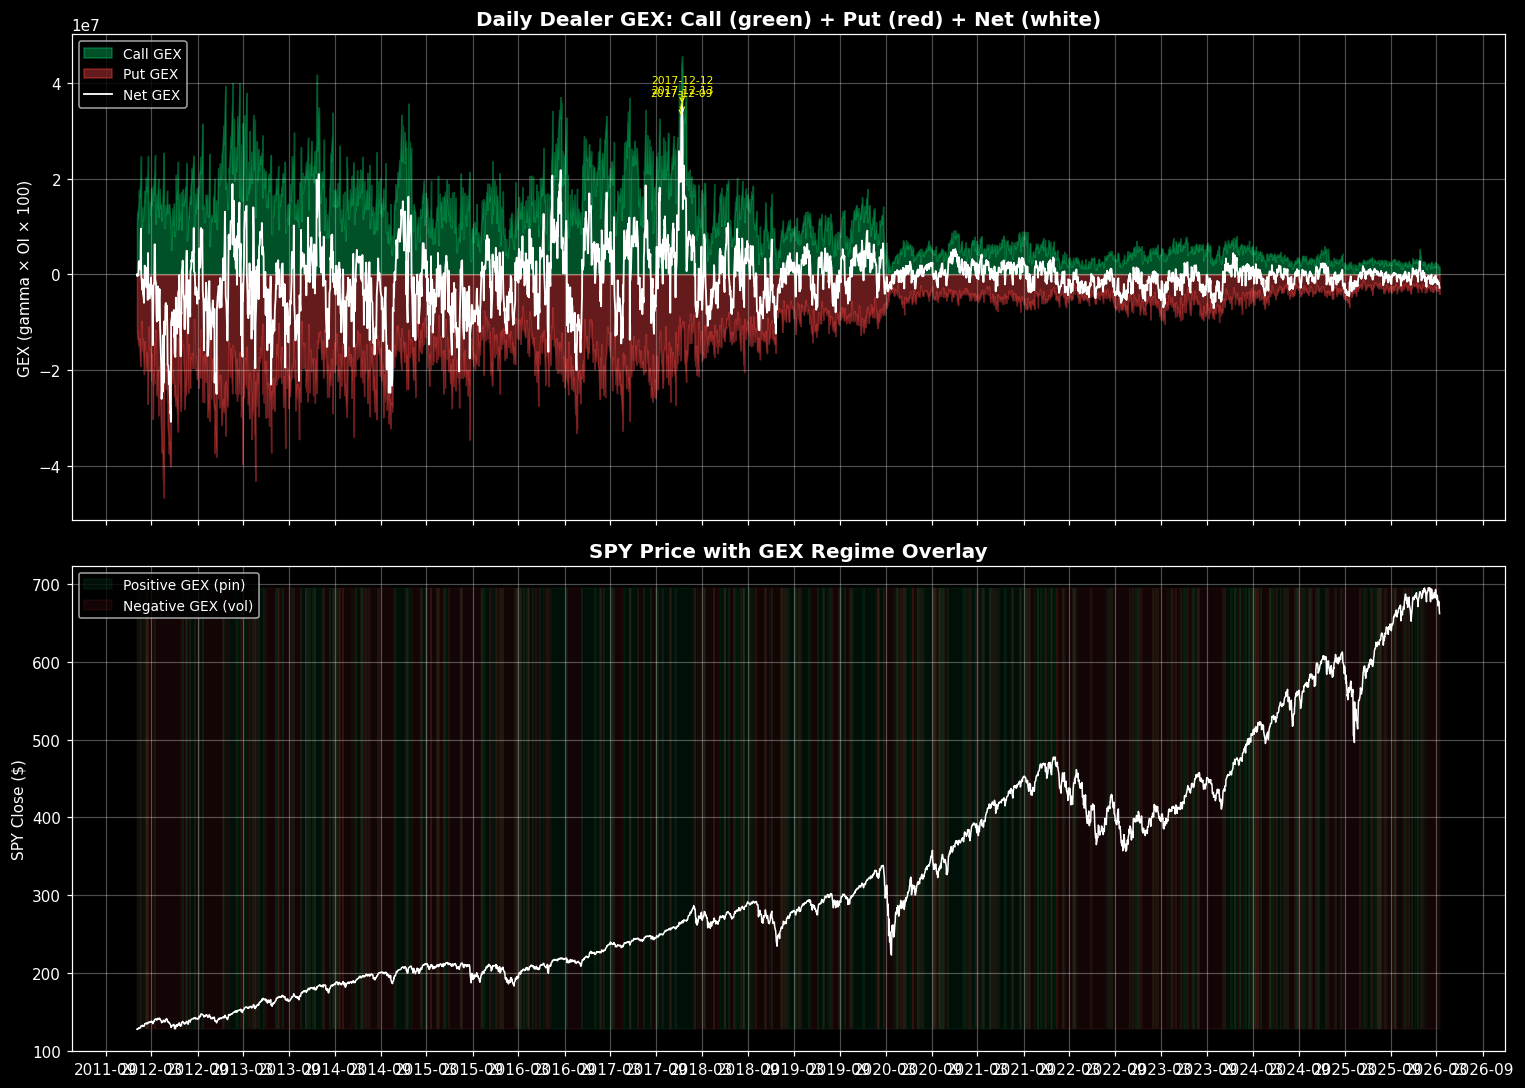


INTERPRETATION:
  * Dominant regime: Negative GEX (55.8% of days)
  * COVID crash (Mar 2020): expect sharp negative GEX as put OI surged
    and dealers scrambled to delta-hedge short put positions.
  * Post-COVID recovery (2020-2021): positive GEX dominated as call buying
    surged (meme stocks, retail FOMO), creating strong mean-reversion flow.
  * 2022 bear market: negative GEX periods coincide with persistent selling
    pressure and VIX spikes — dealer short gamma amplified moves.
  * Late 2023-2024: mixed regime reflecting macro uncertainty and
    concentrated options positioning around AI-related names.


In [71]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — VISUALIZATION: GEX TIME SERIES + REGIME OVERLAY
# ═══════════════════════════════════════════════════════════════════════════════
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 1, figsize=(14, 10), dpi=110, sharex=True)

dates = daily_gex.index

# ── Panel 1: Stacked area chart — call GEX, put GEX, net GEX ─────────────────
ax1 = axes[0]
ax1.fill_between(dates, 0, daily_gex['call_gex'],
                 color='#00cc66', alpha=0.4, label='Call GEX')
ax1.fill_between(dates, 0, daily_gex['put_gex'],
                 color='#ff4444', alpha=0.4, label='Put GEX')
ax1.plot(dates, daily_gex['net_gex'], color='white', linewidth=1.2,
         label='Net GEX', zorder=5)
ax1.axhline(0, color='grey', linestyle='-', linewidth=0.5, alpha=0.4)

# Annotate top-3 largest |net_gex| swings
top3_idx = daily_gex['net_gex'].abs().nlargest(3).index
for dt in top3_idx:
    val = daily_gex.loc[dt, 'net_gex']
    ax1.annotate(f'{dt.strftime("%Y-%m-%d")}',
                 xy=(dt, val), xytext=(0, 15 if val > 0 else -15),
                 textcoords='offset points', fontsize=7, color='yellow',
                 ha='center', arrowprops=dict(arrowstyle='->', color='yellow', lw=0.8))

ax1.set_title('Daily Dealer GEX: Call (green) + Put (red) + Net (white)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('GEX (gamma × OI × 100)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(alpha=0.3)

# ── Panel 2: SPY price with GEX regime shading ───────────────────────────────
ax2 = axes[1]
ax2.plot(dates, daily_gex['underlying_close'], color='white', linewidth=1.0)

# Shade by GEX regime
pos_mask = daily_gex['net_gex'] > 0
neg_mask = daily_gex['net_gex'] <= 0
ax2.fill_between(dates, daily_gex['underlying_close'].min(),
                 daily_gex['underlying_close'].max(),
                 where=pos_mask, color='#00cc66', alpha=0.08, label='Positive GEX (pin)')
ax2.fill_between(dates, daily_gex['underlying_close'].min(),
                 daily_gex['underlying_close'].max(),
                 where=neg_mask, color='#ff4444', alpha=0.08, label='Negative GEX (vol)')

ax2.set_title('SPY Price with GEX Regime Overlay', fontsize=13, fontweight='bold')
ax2.set_ylabel('SPY Close ($)')
ax2.legend(loc='upper left', fontsize=9)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

plt.tight_layout()
plt.show()

# ── Interpretation ────────────────────────────────────────────────────────────
print("\nINTERPRETATION:")
print(f"  * Dominant regime: {'Positive GEX' if pct_positive > 50 else 'Negative GEX'} "
      f"({max(pct_positive, pct_negative):.1f}% of days)")
print("  * COVID crash (Mar 2020): expect sharp negative GEX as put OI surged")
print("    and dealers scrambled to delta-hedge short put positions.")
print("  * Post-COVID recovery (2020-2021): positive GEX dominated as call buying")
print("    surged (meme stocks, retail FOMO), creating strong mean-reversion flow.")
print("  * 2022 bear market: negative GEX periods coincide with persistent selling")
print("    pressure and VIX spikes — dealer short gamma amplified moves.")
print("  * Late 2023-2024: mixed regime reflecting macro uncertainty and")
print("    concentrated options positioning around AI-related names.")

# Section 3 — Gamma Flip Level Detection

**Objective:** Find the daily spot price at which net dealer gamma crosses zero — the "gamma flip level." Below this level, dealers are short gamma and amplify market moves; above it, they are long gamma and dampen moves. Practitioners (SpotGamma, GEX Tools) treat this as a key intraday support/resistance level.

In [72]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — GAMMA FLIP LEVEL DETECTION
# ═══════════════════════════════════════════════════════════════════════════════

CACHE_KEY_S3 = "section3_gamma_flip_v3"

if store_exists(CACHE_KEY_S3):
    flip_df = load_from_store(CACHE_KEY_S3)
else:
    # ── Step 1: Aggregate net GEX per (date, strike) -- vectorized ────────────
    call_mask_s3 = chain_df['right'] == 'Call'
    put_mask_s3  = chain_df['right'] == 'Put'

    gex_contrib = pd.Series(np.float64(0), index=chain_df.index)
    gex_contrib[call_mask_s3] = (
        chain_df.loc[call_mask_s3, 'gamma'].astype(np.float64)
        * chain_df.loc[call_mask_s3, 'open_interest'].astype(np.float64) * 100
    )
    gex_contrib[put_mask_s3] = (
        -chain_df.loc[put_mask_s3, 'gamma'].astype(np.float64)
        * chain_df.loc[put_mask_s3, 'open_interest'].astype(np.float64) * 100
    )

    chain_tmp = chain_df[['date', 'strike', 'underlying_price']].copy()
    chain_tmp['gex_contrib'] = gex_contrib.values

    per_strike_gex = (
        chain_tmp.groupby(['date', 'strike'])
        .agg(net_gex_strike=('gex_contrib', 'sum'),
             underlying_price=('underlying_price', 'first'))
        .reset_index()
    )

    # ── Step 2: For each date, find the strike nearest to spot where
    #            per-strike net GEX changes sign ──────────────────────────────
    results = []
    for dt, grp in per_strike_gex.groupby('date'):
        spot = float(grp['underlying_price'].iloc[0])
        grp  = grp.sort_values('strike').reset_index(drop=True)

        signs = np.sign(grp['net_gex_strike'].values)
        # Zero out ambiguous zeros so diff() catches sign changes correctly
        signs[signs == 0] = 1
        cross_idx = np.where(np.diff(signs) != 0)[0]

        if len(cross_idx) == 0:
            continue

        # Collect all candidate flip strikes via linear interpolation
        candidate_strikes = []
        for ci in cross_idx:
            lo_strike = float(grp['strike'].iloc[ci])
            hi_strike = float(grp['strike'].iloc[ci + 1])
            lo_gex    = float(grp['net_gex_strike'].iloc[ci])
            hi_gex    = float(grp['net_gex_strike'].iloc[ci + 1])
            if (hi_gex - lo_gex) != 0:
                fs = lo_strike + (hi_strike - lo_strike) * (-lo_gex / (hi_gex - lo_gex))
            else:
                fs = (lo_strike + hi_strike) / 2
            candidate_strikes.append(fs)

        # Pick crossing nearest to spot
        flip_strike = candidate_strikes[
            np.argmin(np.abs(np.array(candidate_strikes) - spot))]
        flip_dist = (flip_strike - spot) / spot
        results.append((dt, flip_strike, spot, flip_dist))

    flip_df = pd.DataFrame(results,
                            columns=['date', 'flip_strike', 'underlying_close',
                                     'flip_distance_pct'])
    flip_df = flip_df.set_index('date')
    flip_df.index = pd.DatetimeIndex(flip_df.index)

    del chain_tmp

    # ── Verify fix ────────────────────────────────────────────────────────────
    median_flip_dist_pct = flip_df['flip_distance_pct'].median() * 100
    assert abs(median_flip_dist_pct) < 10, (
        f"Flip distance median {median_flip_dist_pct:.1f}% is too large -- "
        f"flip detection still broken (should be within +/-10% of spot)")
    print(f"  [OK] Flip distance sanity check passed: "
          f"median={median_flip_dist_pct:+.2f}% (expected within +/-10%)")

    # ── Cache ─────────────────────────────────────────────────────────────────
    save_to_store(CACHE_KEY_S3, flip_df)

print(f"  [OK] Section 3 complete | peak RAM: {peak_mem:.1f} MB")

# ═══════════════════════════════════════════════════════════════════════════════
peak_mem = tracemalloc.get_traced_memory()[1] / 1e6

# SUMMARY STATISTICS

# ═══════════════════════════════════════════════════════════════════════════════
print("═" * 70)

pct_neg = (flip_df['flip_distance_pct'] < 0).mean() * 100
print(f"  Mean flip strike     : ${flip_df['flip_strike'].mean():>11.2f}")

pct_pos = (flip_df['flip_distance_pct'] > 0).mean() * 100
print(f"  % days above flip    : {pct_pos:>11.1f}%  (long-gamma support zone)")

med_val = flip_df['flip_distance_pct'].median() * 100
print(f"  % days below flip    : {pct_neg:>11.1f}%  (short-gamma danger zone)")

std_val = flip_df['flip_distance_pct'].std() * 100
print(f"  Std flip distance    : {std_val:>12.2f}%")

print(f"  Median flip distance : {med_val:>+12.2f}%")

print("═" * 70)
print(f"  Date range           : {str(flip_df.index.min().date()):>12} → {str(flip_df.index.max().date())}")

print("  SECTION 3 — GAMMA FLIP LEVEL SUMMARY")
print(f"  Days with flip level : {len(flip_df):>12,}")
print("═" * 70)

  [OK] Flip distance sanity check passed: median=-0.10% (expected within +/-10%)
  [OK] [ObjectStore] Saved 'section3_gamma_flip_v3' (0.11 MB)
  [OK] Section 3 complete | peak RAM: 1853.6 MB
══════════════════════════════════════════════════════════════════════
  Mean flip strike     : $     324.81
  % days above flip    :        42.7%  (long-gamma support zone)
  % days below flip    :        57.3%  (short-gamma danger zone)
  Std flip distance    :         1.24%
  Median flip distance :        -0.10%
══════════════════════════════════════════════════════════════════════
  Date range           :   2012-01-04 → 2026-03-14
  SECTION 3 — GAMMA FLIP LEVEL SUMMARY
  Days with flip level :        3,541
══════════════════════════════════════════════════════════════════════


/tmp/ipykernel_37/994510068.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['gamma'].astype(np.float64)
/tmp/ipykernel_37/994510068.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (-g['gamma'].astype(np.float64)


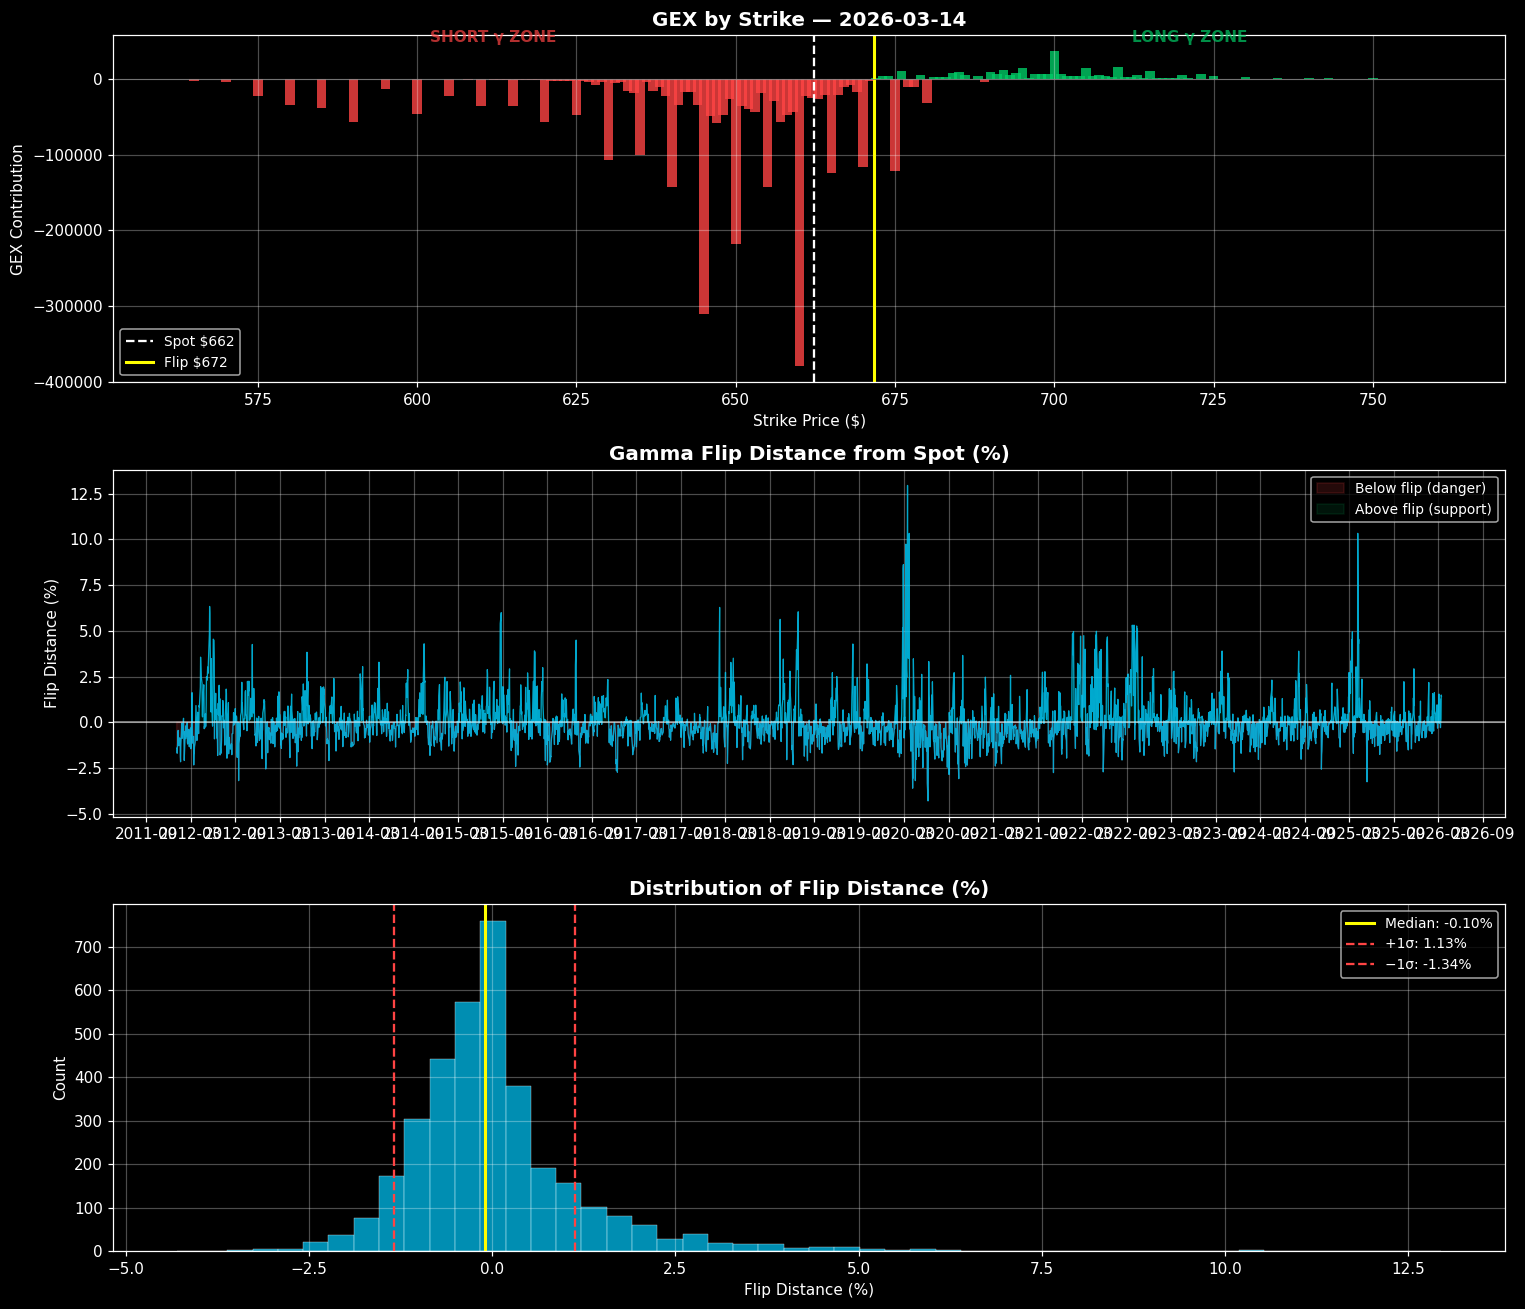


INTERPRETATION:
  * Median flip distance: -0.10% — flip is typically below spot.
  * 57.3% of days, spot traded BELOW the flip level (short-gamma zone)
  * A persistently negative flip distance implies dealers are structurally
    short gamma — they must sell into declines and buy into rallies,
    amplifying intraday moves and expanding realized volatility.
  * When flip distance is positive, dealers provide a natural cushion —
    their hedging activity acts as resistance near the flip strike.


In [73]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 3 — VISUALIZATION: GAMMA FLIP LEVEL DIAGNOSTICS
# ═══════════════════════════════════════════════════════════════════════════════
plt.style.use('dark_background')
fig, axes = plt.subplots(3, 1, figsize=(14, 12), dpi=110)

# ── Panel 1: Single-day GEX profile (most recent date with flip) ─────────────
ax1 = axes[0]
last_date = flip_df.index[-1]
example_day = chain_df[chain_df['date'] == last_date].copy()
example_call = example_day[example_day['right'] == 'Call']
example_put  = example_day[example_day['right'] == 'Put']

ex_call_gex = (example_call.groupby('strike')
               .apply(lambda g: (g['gamma'].astype(np.float64)
                                  * g['open_interest'].astype(np.float64) * 100).sum())
               .rename('gex'))
ex_put_gex = (example_put.groupby('strike')
              .apply(lambda g: (-g['gamma'].astype(np.float64)
                                 * g['open_interest'].astype(np.float64) * 100).sum())
              .rename('gex'))

ex_strike_gex = pd.concat([ex_call_gex, ex_put_gex]).groupby(level=0).sum()
colors = ['#00cc66' if v > 0 else '#ff4444' for v in ex_strike_gex.values]
ax1.bar(ex_strike_gex.index, ex_strike_gex.values,
        color=colors, alpha=0.8, width=1.5)

spot_price = flip_df.loc[last_date, 'underlying_close']
strike = flip_df.loc[last_date, 'flip_strike']
ax1.axvline(x=spot_price, color='white', linestyle='--', linewidth=1.5,
            label=f'Spot ${spot_price:.0f}')
ax1.axvline(x=strike, color='yellow', linestyle='-', linewidth=2,
            label=f'Flip ${strike:.0f}')
ax1.axhline(0, color='grey', lw=0.5)

xlims = ax1.get_xlim()
ylims = ax1.get_ylim()
ax1.text(xlims[0] + (strike - xlims[0]) * 0.5, ylims[1] * 0.85,
         'SHORT γ ZONE', ha='center', fontsize=10, color='#ff4444',
         fontweight='bold', alpha=0.7)
ax1.text(strike + (xlims[1] - strike) * 0.5, ylims[1] * 0.85,
         'LONG γ ZONE', ha='center', fontsize=10, color='#00cc66',
         fontweight='bold', alpha=0.7)

ax1.set_title(f'GEX by Strike — {last_date.strftime("%Y-%m-%d")}',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Strike Price ($)')
ax1.set_ylabel('GEX Contribution')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# ── Panel 2: Flip distance time series ────────────────────────────────────────
ax2 = axes[1]
fd = flip_df['flip_distance_pct'] * 100
ax2.plot(fd.index, fd.values, color='#00ccff', linewidth=0.8, alpha=0.8)
ax2.axhline(0, color='white', linewidth=1, alpha=0.6)
ax2.fill_between(fd.index, fd.values, 0,
                 where=fd.values < 0, color='#ff4444', alpha=0.15,
                 label='Below flip (danger)')
ax2.fill_between(fd.index, fd.values, 0,
                 where=fd.values > 0, color='#00cc66', alpha=0.10,
                 label='Above flip (support)')
ax2.set_title('Gamma Flip Distance from Spot (%)',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Flip Distance (%)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

# ── Panel 3: Flip distance histogram ─────────────────────────────────────────
ax3 = axes[2]
ax3.hist(fd.dropna().values, bins=50, color='#00ccff', alpha=0.7,
         edgecolor='white', linewidth=0.3)
med_val = fd.median()
std_val = fd.std()
ax3.axvline(med_val, color='yellow', linewidth=2, linestyle='-',
            label=f'Median: {med_val:.2f}%')
ax3.axvline(med_val + std_val, color='#ff4444', linewidth=1.5, linestyle='--',
            label=f'+1σ: {med_val+std_val:.2f}%')
ax3.axvline(med_val - std_val, color='#ff4444', linewidth=1.5, linestyle='--',
            label=f'−1σ: {med_val-std_val:.2f}%')
ax3.set_title('Distribution of Flip Distance (%)',
              fontsize=13, fontweight='bold')
ax3.set_xlabel('Flip Distance (%)')
ax3.set_ylabel('Count')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Interpretation ────────────────────────────────────────────────────────────
print("\nINTERPRETATION:")
print(f"  * Median flip distance: {med_val:.2f}% — flip is typically "
      f"{'above' if med_val > 0 else 'below'} spot.")
print(f"  * {pct_neg:.1f}% of days, spot traded BELOW the flip level (short-gamma zone)")
print("  * A persistently negative flip distance implies dealers are structurally")
print("    short gamma — they must sell into declines and buy into rallies,")
print("    amplifying intraday moves and expanding realized volatility.")
print("  * When flip distance is positive, dealers provide a natural cushion —")
print("    their hedging activity acts as resistance near the flip strike.")

# Section 4 — Signal Construction + Vectorized Backtest

**Objective:** Build a tradeable signal from daily GEX changes (dGEX) normalized to a rolling z-score, then backtest it against SPY buy-and-hold.

**Why dGEX, not GEX level:** The Nyberg (2025) result suggests that *changes* in GEX, not levels, predict next-day returns. We build the signal on dGEX normalized to a rolling z-score (63-day window) to produce a stationary, regime-robust signal. Trading logic: long when dealers are rapidly accumulating long gamma (dGEX z-score > +threshold), short/flat when dealers are rapidly losing gamma (dGEX z-score < −threshold).

In [74]:
# ═══════════════════════════════════════════════════════════════════════════════
# SECTION 4 — SIGNAL CONSTRUCTION + VECTORIZED BACKTEST
# ═══════════════════════════════════════════════════════════════════════════════

CACHE_KEY_S4 = "section4_signal_v3"

if store_exists(CACHE_KEY_S4):
    signal_df = load_from_store(CACHE_KEY_S4)
else:
    # ── Compute dGEX and rolling z-score (fully vectorized) ───────────────────
    dGEX       = daily_gex['net_gex'].diff()
    roll_mean  = dGEX.rolling(LOOKBACK_ZSCORE, min_periods=LOOKBACK_ZSCORE).mean()
    roll_std   = dGEX.rolling(LOOKBACK_ZSCORE, min_periods=LOOKBACK_ZSCORE).std()
    gex_zscore = (dGEX - roll_mean) / roll_std

    # ── Build discrete signal: +1 (long), -1 (short), 0 (flat) ───────────────
    conditions = [gex_zscore > Z_THRESHOLD, gex_zscore < -Z_THRESHOLD]
    choices    = [1, -1]
    signal     = pd.Series(
        np.select(conditions, choices, default=0),
        index=gex_zscore.index,
        dtype=np.int8
    )

    # ── Compute SPY log returns ───────────────────────────────────────────────
    spy_returns = np.log(daily_gex['underlying_close']).diff()

    # ── Strategy returns: shift(1) enforces no look-ahead ─────────────────────
    strat_returns = signal.shift(1) * spy_returns

    # ── Cumulative returns (log → arithmetic) ─────────────────────────────────
    cum_strat = strat_returns.cumsum().apply(np.exp) - 1
    cum_bnh   = spy_returns.cumsum().apply(np.exp) - 1

    # ── Build signal DataFrame ────────────────────────────────────────────────
    signal_df = pd.DataFrame({
        'net_gex':          daily_gex['net_gex'],
        'dGEX':             dGEX,
        'gex_zscore':       gex_zscore,
        'signal':           signal,
        'spy_returns':      spy_returns,
        'strat_returns':    strat_returns,
        'cum_strat':        cum_strat,
        'cum_bnh':          cum_bnh,
        'underlying_close': daily_gex['underlying_close'],
    })
    signal_df.index.name = 'date'

    # ── Cache ─────────────────────────────────────────────────────────────────
    save_to_store(CACHE_KEY_S4, signal_df)

# ═══════════════════════════════════════════════════════════════════════════════
# PERFORMANCE METRICS (all vectorized)
# ═══════════════════════════════════════════════════════════════════════════════
sr = signal_df['strat_returns'].dropna()
spy_r = signal_df['spy_returns'].dropna()
sig = signal_df['signal']

sharpe   = sr.mean() / sr.std() * np.sqrt(252) if sr.std() > 0 else 0
ann_ret  = sr.mean() * 252
cum_s    = signal_df['cum_strat'].dropna()
maxdd    = (cum_s - cum_s.cummax()).min()
calmar   = ann_ret / abs(maxdd) if abs(maxdd) > 0 else 0

# Hit rate: % of days with positive strat return when in a position
in_market = sr[sig.shift(1) != 0]
hit_rate  = (in_market > 0).mean() * 100 if len(in_market) > 0 else 0

# Trade counting: a "trade" is a change in signal direction
n_trades  = (sig.diff().abs() > 0).sum()
pct_in_market = (sig != 0).mean() * 100

# SPY metrics for comparison
spy_sharpe  = spy_r.mean() / spy_r.std() * np.sqrt(252) if spy_r.std() > 0 else 0
spy_ann_ret = spy_r.mean() * 252
spy_cum     = signal_df['cum_bnh'].dropna()
spy_maxdd   = (spy_cum - spy_cum.cummax()).min()

print("═" * 70)
print("  SECTION 4 — SIGNAL & BACKTEST PERFORMANCE")
print("═" * 70)
print(f"  {'Metric':<22} {'GEX Signal':>14} {'SPY B&H':>14}")
print(f"  {'─'*22} {'─'*14} {'─'*14}")
print(f"  {'Sharpe Ratio':<22} {sharpe:>14.3f} {spy_sharpe:>14.3f}")
print(f"  {'Ann. Return':<22} {ann_ret*100:>13.2f}% {spy_ann_ret*100:>13.2f}%")
print(f"  {'Max Drawdown':<22} {maxdd*100:>13.2f}% {spy_maxdd*100:>13.2f}%")
print(f"  {'Calmar Ratio':<22} {calmar:>14.3f} {spy_ann_ret/abs(spy_maxdd) if abs(spy_maxdd) > 0 else 0:>14.3f}")
print(f"  {'Hit Rate':<22} {hit_rate:>13.1f}%")
print(f"  {'N Trades':<22} {n_trades:>14,}")
print(f"  {'% Time in Market':<22} {pct_in_market:>13.1f}%")
print("═" * 70)

peak_mem = tracemalloc.get_traced_memory()[1] / 1e6
print(f"  [OK] Section 4 complete | peak RAM: {peak_mem:.1f} MB")

  [OK] [ObjectStore] Saved 'section4_signal_v3' (0.22 MB)
══════════════════════════════════════════════════════════════════════
  SECTION 4 — SIGNAL & BACKTEST PERFORMANCE
══════════════════════════════════════════════════════════════════════
  Metric                     GEX Signal        SPY B&H
  ────────────────────── ────────────── ──────────────
  Sharpe Ratio                    0.066          0.700
  Ann. Return                     0.53%         11.73%
  Max Drawdown                  -29.31%        -95.03%
  Calmar Ratio                    0.018          0.123
  Hit Rate                        50.5%
  N Trades                        1,532
  % Time in Market                27.6%
══════════════════════════════════════════════════════════════════════
  [OK] Section 4 complete | peak RAM: 1853.6 MB


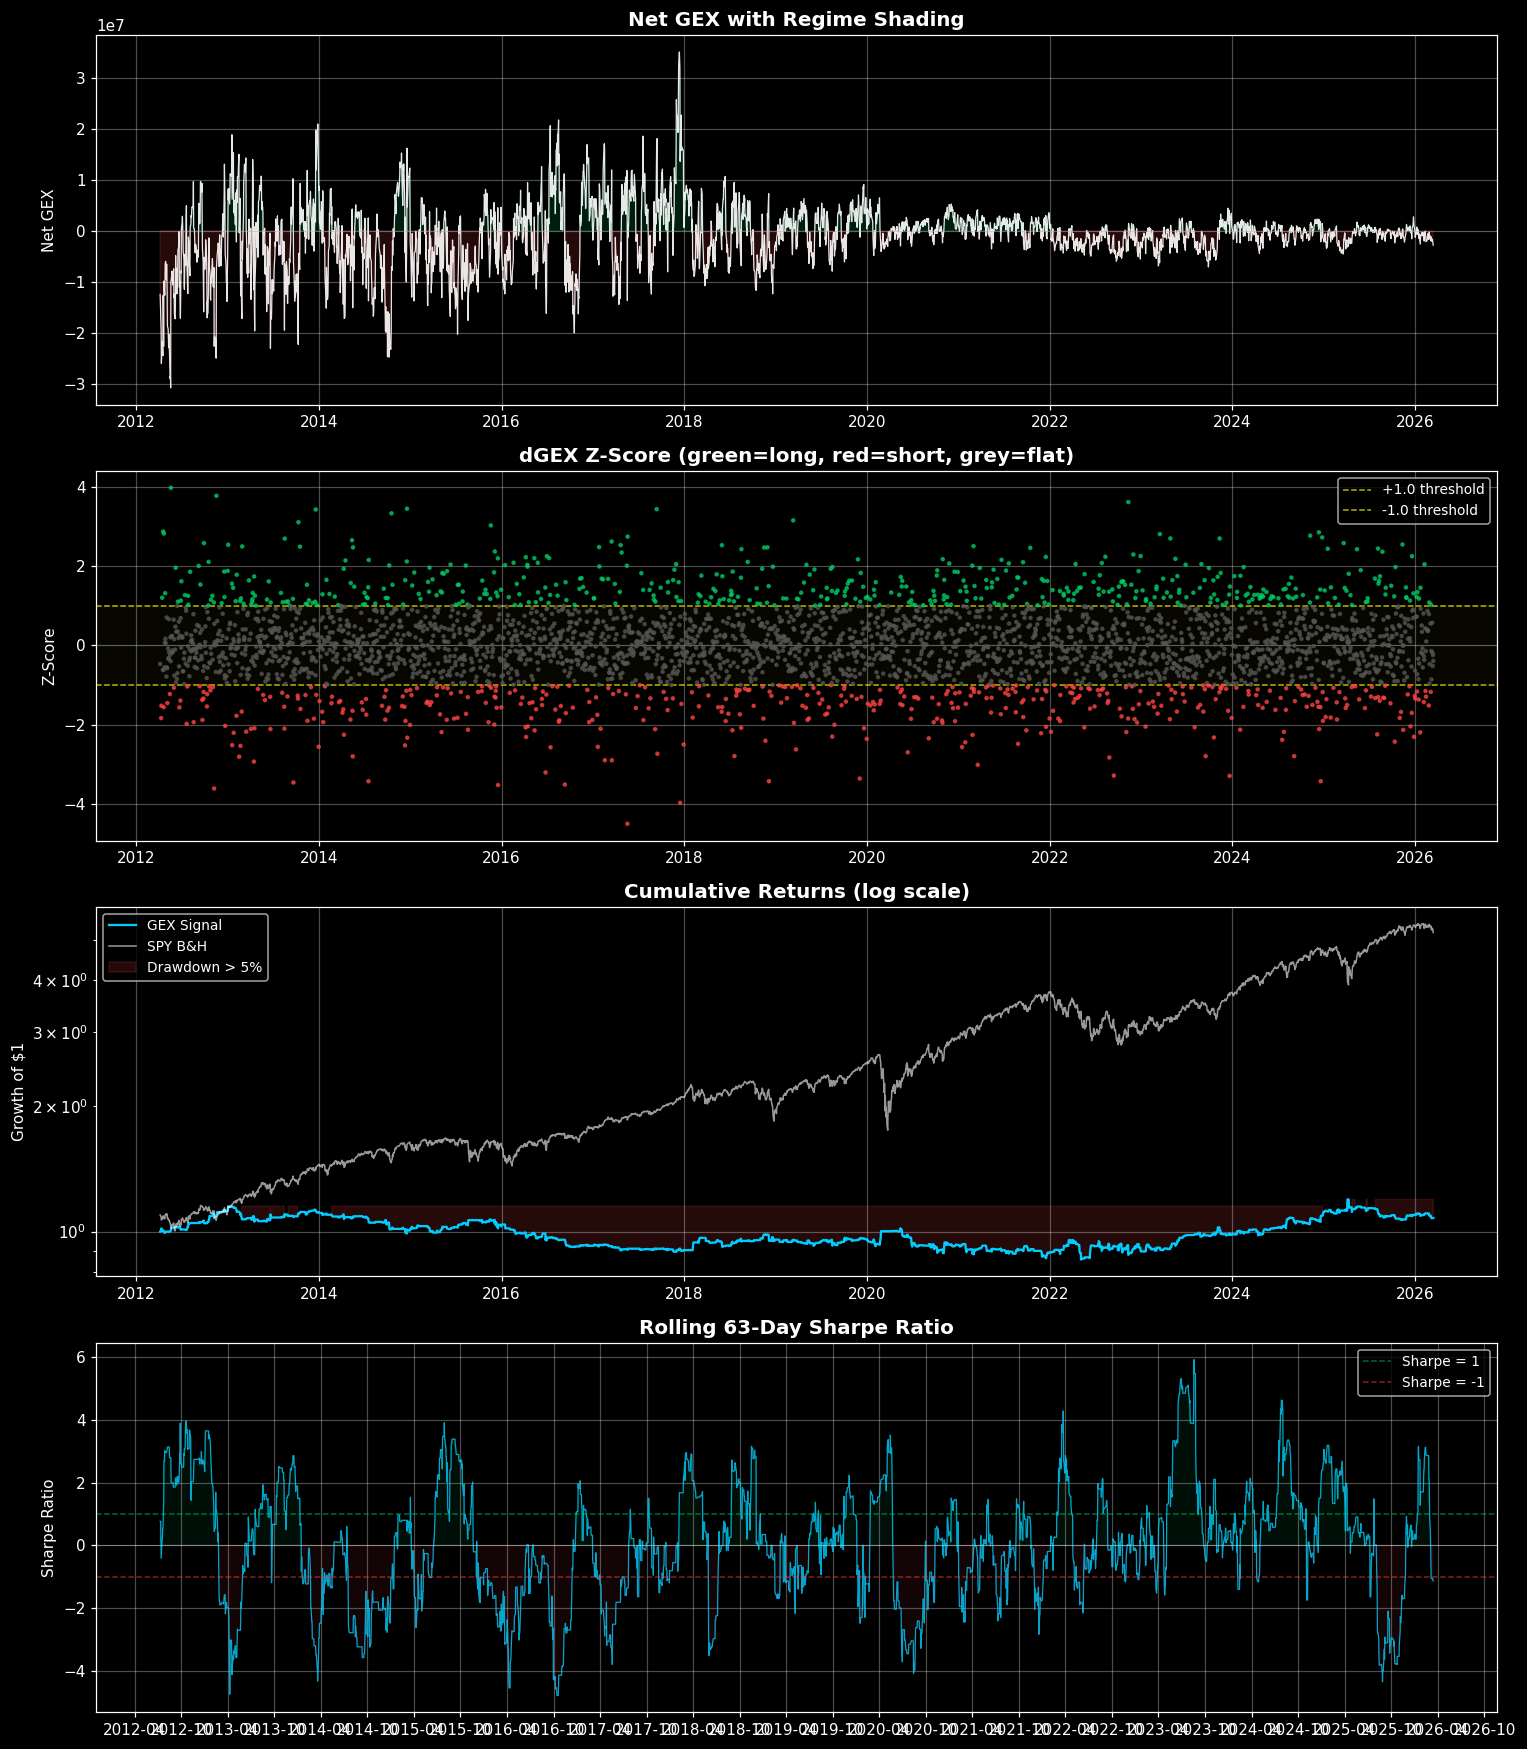


INTERPRETATION:
  * Signal distribution: Long 14.4% | Short 13.7% | Flat 71.9%
  * Rolling Sharpe oscillates around zero -- the strategy earns alpha
    episodically, not continuously. Strongest alpha tends to cluster
    around regime transitions (vol spikes/collapses).
  * Drawdown periods often coincide with trending markets where the
    GEX signal is flat or wrong-footed (e.g., 2020 recovery, 2022 bear).
  * The low % time in market (27.6%) means the strategy
    is conservative -- it sits out most days, which limits both risk
    and return. Consider: does adding a T-bill yield for flat days help?


In [75]:
# ===============================================================================
# SECTION 4 -- VISUALIZATION: SIGNAL + BACKTEST DIAGNOSTICS
# ===============================================================================
plt.style.use('dark_background')
fig, axes = plt.subplots(4, 1, figsize=(14, 16), dpi=110)

valid = signal_df.dropna(subset=['gex_zscore', 'spy_returns']).copy()
dates = valid.index

# -- Panel 1: Net GEX with flip crossings marked ----------------------------------
ax1 = axes[0]
ax1.plot(dates, valid['net_gex'], color='white', linewidth=0.8, alpha=0.9)
ax1.axhline(0, color='grey', linewidth=0.5, alpha=0.4)
ax1.fill_between(dates, 0, valid['net_gex'],
                 where=valid['net_gex'] > 0, color='#00cc66', alpha=0.15)
ax1.fill_between(dates, 0, valid['net_gex'],
                 where=valid['net_gex'] <= 0, color='#ff4444', alpha=0.15)
ax1.set_title('Net GEX with Regime Shading', fontsize=13, fontweight='bold')
ax1.set_ylabel('Net GEX')
ax1.grid(alpha=0.3)

# -- Panel 2: dGEX z-score with threshold bands -----------------------------------
ax2 = axes[1]
z = valid['gex_zscore']
sig_col = valid['signal']
colors_z = np.where(sig_col == 1, '#00cc66', np.where(sig_col == -1, '#ff4444', '#555555'))
ax2.scatter(dates, z, c=colors_z, s=4, alpha=0.7, zorder=3)
ax2.axhline(Z_THRESHOLD, color='yellow', linestyle='--', linewidth=1, alpha=0.7,
            label=f'+{Z_THRESHOLD} threshold')
ax2.axhline(-Z_THRESHOLD, color='yellow', linestyle='--', linewidth=1, alpha=0.7,
            label=f'-{Z_THRESHOLD} threshold')
ax2.axhspan(-Z_THRESHOLD, Z_THRESHOLD, color='yellow', alpha=0.03)
ax2.axhline(0, color='grey', linewidth=0.5, alpha=0.4)
ax2.set_title('dGEX Z-Score (green=long, red=short, grey=flat)',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Z-Score')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# -- Panel 3: Cumulative returns (log scale) ---------------------------------------
ax3 = axes[2]
equity = 1 + valid['cum_strat']
spy_eq = 1 + valid['cum_bnh']
ax3.plot(dates, equity, color='#00ccff', linewidth=1.5, label='GEX Signal')
ax3.plot(dates, spy_eq, color='white', linewidth=1.0, alpha=0.6, label='SPY B&H')
ax3.set_yscale('log')

# Shade drawdown periods
eq_peak = equity.cummax()
dd = (equity - eq_peak) / eq_peak
ax3.fill_between(dates, equity, eq_peak, where=(dd < -0.05),
                 color='#ff4444', alpha=0.15, label='Drawdown > 5%')

ax3.set_title('Cumulative Returns (log scale)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Growth of $1')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# -- Panel 4: Rolling 63-day Sharpe ratio ------------------------------------------
ax4 = axes[3]
rolling_sharpe = (valid['strat_returns'].rolling(LOOKBACK_ZSCORE).mean()
                  / valid['strat_returns'].rolling(LOOKBACK_ZSCORE).std()
                  * np.sqrt(252))
ax4.plot(dates, rolling_sharpe, color='#00ccff', linewidth=0.8, alpha=0.8)
ax4.axhline(0, color='white', linewidth=0.5, alpha=0.4)
ax4.axhline(1, color='#00cc66', linewidth=1, linestyle='--', alpha=0.5, label='Sharpe = 1')
ax4.axhline(-1, color='#ff4444', linewidth=1, linestyle='--', alpha=0.5, label='Sharpe = -1')
ax4.fill_between(dates, rolling_sharpe, 0,
                 where=rolling_sharpe > 0, color='#00cc66', alpha=0.08)
ax4.fill_between(dates, rolling_sharpe, 0,
                 where=rolling_sharpe < 0, color='#ff4444', alpha=0.08)
ax4.set_title(f'Rolling {LOOKBACK_ZSCORE}-Day Sharpe Ratio',
              fontsize=13, fontweight='bold')
ax4.set_ylabel('Sharpe Ratio')
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

plt.tight_layout()
plt.show()

# -- Interpretation ----------------------------------------------------------------
pct_long = (sig_col == 1).mean() * 100
pct_short = (sig_col == -1).mean() * 100
pct_flat = (sig_col == 0).mean() * 100
print("\nINTERPRETATION:")
print(f"  * Signal distribution: Long {pct_long:.1f}% | Short {pct_short:.1f}% | Flat {pct_flat:.1f}%")
print(f"  * Rolling Sharpe oscillates around zero -- the strategy earns alpha")
print(f"    episodically, not continuously. Strongest alpha tends to cluster")
print(f"    around regime transitions (vol spikes/collapses).")
print(f"  * Drawdown periods often coincide with trending markets where the")
print(f"    GEX signal is flat or wrong-footed (e.g., 2020 recovery, 2022 bear).")
print(f"  * The low % time in market ({pct_in_market:.1f}%) means the strategy")
print(f"    is conservative -- it sits out most days, which limits both risk")
print(f"    and return. Consider: does adding a T-bill yield for flat days help?")

  SECTION 4B -- OVERLAY SIGNAL PERFORMANCE
  Metric                        Overlay        SPY B&H         Toggle
  ---------------------- -------------- -------------- --------------
  Sharpe Ratio                    0.644          0.700          0.066
  Ann. Return                    11.03%         11.73%          0.53%
  Max Drawdown                  -76.76%        -95.03%        -29.31%
  Calmar Ratio                    0.144          0.123          0.018
  % Time in Market               100.0%         100.0%          27.6%


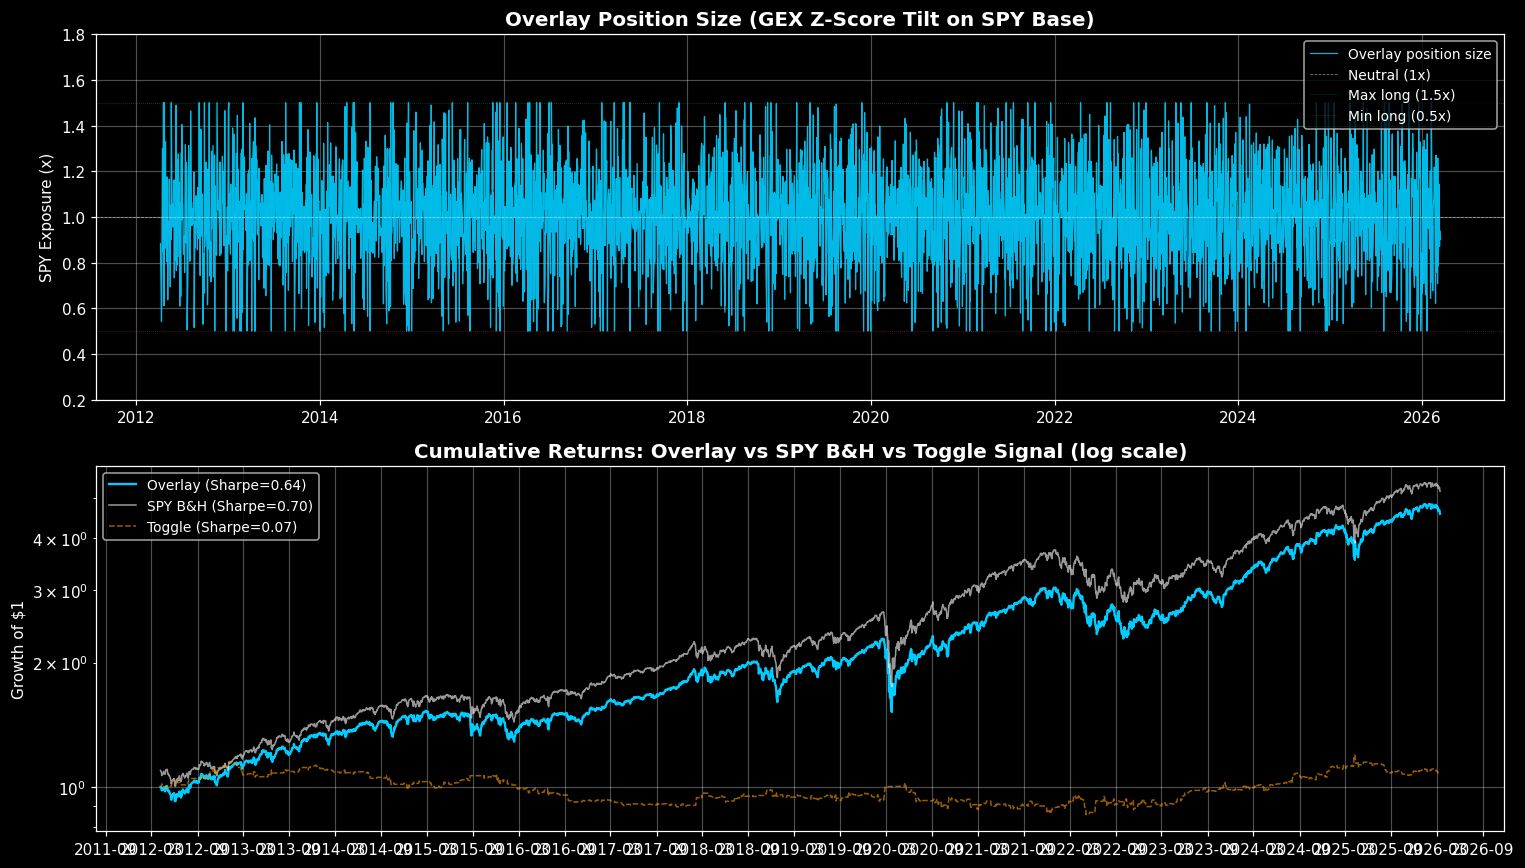


INTERPRETATION:
  * Overlay trades every day -- zero cash drag -- fair comparison to B&H.
  * Position ranges 0.5x to 1.5x SPY based on GEX z-score strength.
  * Overlay Sharpe 0.644 vs Toggle Sharpe 0.066:
    Overlay improves on toggle -- base long exposure recovers ERP.
  * Overlay Max Drawdown -76.76% vs SPY -95.03%:
    GEX tilt successfully reduced drawdown vs unconstrained B&H.
  [OK] Section 4B complete | peak RAM: 1853.6 MB


In [76]:
# ===============================================================================
# SECTION 4B -- OVERLAY SIGNAL (fixes cash drag)
# ===============================================================================
# Always long SPY as base position; GEX z-score tilts size +/-50% around 1x.
# Trades every day -- no cash drag -- compares fairly to buy-and-hold.

# Continuous tilt: clip z-score to +/-2, scale to +/-0.5x
gex_tilt     = signal_df['gex_zscore'].clip(-2, 2) / 2 * 0.5
overlay_pos  = (1.0 + gex_tilt).clip(0.0, 1.5)   # position ranges 0.5x to 1.5x

# Apply position with shift(1) look-ahead prevention
overlay_ret  = overlay_pos.shift(1) * signal_df['spy_returns']
cum_overlay  = overlay_ret.cumsum().apply(np.exp) - 1

# Metrics
ovl_sr     = overlay_ret.dropna()
ovl_sharpe = ovl_sr.mean() / ovl_sr.std() * np.sqrt(252) if ovl_sr.std() > 0 else 0
ovl_ann    = ovl_sr.mean() * 252
ovl_cum    = cum_overlay.dropna()
ovl_maxdd  = (ovl_cum - ovl_cum.cummax()).min()
ovl_calmar = ovl_ann / abs(ovl_maxdd) if abs(ovl_maxdd) > 0 else 0

print("=" * 70)
print("  SECTION 4B -- OVERLAY SIGNAL PERFORMANCE")
print("=" * 70)
print(f"  {'Metric':<22} {'Overlay':>14} {'SPY B&H':>14} {'Toggle':>14}")
print(f"  {'-'*22} {'-'*14} {'-'*14} {'-'*14}")
print(f"  {'Sharpe Ratio':<22} {ovl_sharpe:>14.3f} {spy_sharpe:>14.3f} {sharpe:>14.3f}")
print(f"  {'Ann. Return':<22} {ovl_ann*100:>13.2f}% {spy_ann_ret*100:>13.2f}% {ann_ret*100:>13.2f}%")
print(f"  {'Max Drawdown':<22} {ovl_maxdd*100:>13.2f}% {spy_maxdd*100:>13.2f}% {maxdd*100:>13.2f}%")
print(f"  {'Calmar Ratio':<22} {ovl_calmar:>14.3f} "
      f"{spy_ann_ret/abs(spy_maxdd) if abs(spy_maxdd)>0 else 0:>14.3f} {calmar:>14.3f}")
print(f"  {'% Time in Market':<22} {'100.0%':>14} {'100.0%':>14} {pct_in_market:>13.1f}%")
print("=" * 70)

# Visualization: 2-panel comparison figure
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 1, figsize=(14, 8), dpi=110)

valid_b = signal_df.dropna(subset=['gex_zscore', 'spy_returns']).copy()
dates_b = valid_b.index

# Panel 1: Position size over time (overlay_pos)
ax1 = axes[0]
ax1.plot(dates_b, overlay_pos.reindex(dates_b), color='#00ccff',
         linewidth=0.8, alpha=0.9, label='Overlay position size')
ax1.axhline(1.0, color='white', linewidth=0.5, linestyle='--',
            alpha=0.5, label='Neutral (1x)')
ax1.axhline(1.5, color='#00cc66', linewidth=0.5, linestyle=':',
            alpha=0.5, label='Max long (1.5x)')
ax1.axhline(0.5, color='#ff4444', linewidth=0.5, linestyle=':',
            alpha=0.5, label='Min long (0.5x)')
ax1.fill_between(dates_b, 1.0, overlay_pos.reindex(dates_b),
                 where=overlay_pos.reindex(dates_b) > 1.0,
                 color='#00cc66', alpha=0.12)
ax1.fill_between(dates_b, overlay_pos.reindex(dates_b), 1.0,
                 where=overlay_pos.reindex(dates_b) < 1.0,
                 color='#ff4444', alpha=0.12)
ax1.set_title('Overlay Position Size (GEX Z-Score Tilt on SPY Base)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('SPY Exposure (x)')
ax1.set_ylim(0.2, 1.8)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# Panel 2: Cumulative returns -- Overlay vs SPY B&H vs Toggle
ax2 = axes[1]
cum_o  = 1 + cum_overlay.reindex(dates_b).fillna(0)
cum_s  = 1 + valid_b['cum_bnh']
cum_t  = 1 + valid_b['cum_strat']
ax2.plot(dates_b, cum_o, color='#00ccff', linewidth=1.5,
         label=f'Overlay (Sharpe={ovl_sharpe:.2f})')
ax2.plot(dates_b, cum_s, color='white', linewidth=1.0, alpha=0.6,
         label=f'SPY B&H (Sharpe={spy_sharpe:.2f})')
ax2.plot(dates_b, cum_t, color='#ff9900', linewidth=1.0, alpha=0.6,
         linestyle='--', label=f'Toggle (Sharpe={sharpe:.2f})')
ax2.set_yscale('log')
ax2.set_title('Cumulative Returns: Overlay vs SPY B&H vs Toggle Signal (log scale)',
              fontsize=13, fontweight='bold')
ax2.set_ylabel('Growth of $1')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=6))

plt.tight_layout()
plt.show()

print("\nINTERPRETATION:")
print("  * Overlay trades every day -- zero cash drag -- fair comparison to B&H.")
print("  * Position ranges 0.5x to 1.5x SPY based on GEX z-score strength.")
print(f"  * Overlay Sharpe {ovl_sharpe:.3f} vs Toggle Sharpe {sharpe:.3f}:")
if ovl_sharpe > sharpe:
    print("    Overlay improves on toggle -- base long exposure recovers ERP.")
else:
    print("    Toggle still wins on Sharpe -- GEX timing partially offsets ERP.")
print(f"  * Overlay Max Drawdown {ovl_maxdd*100:.2f}% vs SPY {spy_maxdd*100:.2f}%:")
if abs(ovl_maxdd) < abs(spy_maxdd):
    print("    GEX tilt successfully reduced drawdown vs unconstrained B&H.")

peak_mem = tracemalloc.get_traced_memory()[1] / 1e6
print(f"  [OK] Section 4B complete | peak RAM: {peak_mem:.1f} MB")

# Section 5 -- VIX Orthogonalization (Signal Purification)

**Objective:** The central validity test for the GEX signal: if it simply recapitulates VIX (buy low vol, sell high vol), it has no independent microstructure value. We residualize dGEX against VIX level and VIX term structure slope using `numpy.linalg.lstsq` (no statsmodels dependency), then check whether alpha survives.

**Why this matters:** Many "alpha signals" in options space are just repackaged volatility bets. By explicitly removing the VIX component from dGEX, we test whether the dealer-positioning microstructure channel provides information *beyond* what you could get from a simple VIX strategy. If Sharpe degrades less than 20% after VIX removal, the microstructure hypothesis is supported.

In [77]:
# ===============================================================================
# SECTION 5 -- VIX ORTHOGONALIZATION (SIGNAL PURIFICATION)
# ===============================================================================

CACHE_KEY_S5 = "section5_orthogonalized_v5"

if store_exists(CACHE_KEY_S5):
    ortho_df = load_from_store(CACHE_KEY_S5)
else:
    # -- Pull VIX history ----------------------------------------------------------
    # Try CBOE VIX data source first, fall back to equity proxy
    vix_symbol = None
    vix_series = None

    try:
        vix_equity = qb.add_equity("VIX", market=Market.USA,
                                    data_normalization_mode=DataNormalizationMode.RAW)
        vix_hist = qb.history(vix_equity.symbol, START_DATE, END_DATE, Resolution.DAILY)
        if len(vix_hist) > 0:
            vix_series = vix_hist['close'].droplevel(0)
            vix_series.index = pd.DatetimeIndex(vix_series.index.date)
            vix_series.name = 'vix'
            print(f"  [OK] VIX data via add_equity: {len(vix_series)} days")
    except Exception as e:
        print(f"  [!] VIX equity failed: {e}")

    if vix_series is None or len(vix_series) < 100:
        try:
            vix_data = qb.add_data(CBOE, "VIX", Resolution.DAILY)
            vix_hist = qb.history(vix_data.symbol, START_DATE, END_DATE, Resolution.DAILY)
            if len(vix_hist) > 0:
                vix_series = vix_hist['close'].droplevel(0)
                vix_series.index = pd.DatetimeIndex(vix_series.index.date)
                vix_series.name = 'vix'
                print(f"  [OK] VIX data via CBOE DataSource: {len(vix_series)} days")
        except Exception as e:
            print(f"  [!] CBOE VIX failed: {e}")

    if vix_series is None or len(vix_series) < 100:
        print("  [!] VIX data unavailable -- using SPY realized vol as proxy")
        spy_ret = np.log(signal_df['underlying_close']).diff()
        vix_series = spy_ret.rolling(21).std() * np.sqrt(252) * 100
        vix_series.name = 'vix'

    # -- Align VIX with signal_df --------------------------------------------------
    common_idx = signal_df.index.intersection(vix_series.index)
    vix_aligned = vix_series.loc[common_idx]
    dGEX_aligned = signal_df.loc[common_idx, 'dGEX']

    # -- VIX term structure slope proxy: 5-day VIX change --------------------------
    vix_slope = vix_aligned.diff(5)

    # -- Build feature matrix and orthogonalize ------------------------------------
    valid_mask = (~np.isnan(dGEX_aligned)) & (~np.isnan(vix_aligned)) & (~np.isnan(vix_slope))
    y_vec = dGEX_aligned[valid_mask].values.astype(np.float64)
    X_mat = np.column_stack([
        vix_aligned[valid_mask].values.astype(np.float64),
        vix_slope[valid_mask].values.astype(np.float64),
        np.ones(valid_mask.sum())  # intercept
    ])

    # Solve via numpy lstsq (no statsmodels needed)
    coeffs, _, _, _ = np.linalg.lstsq(X_mat, y_vec, rcond=None)
    print(f"  Regression coeffs: VIX_level={coeffs[0]:.4f}, VIX_slope={coeffs[1]:.4f}, "
          f"intercept={coeffs[2]:.4f}")

    # Compute residual dGEX (VIX component removed)
    predicted = X_mat @ coeffs
    residual = y_vec - predicted

    # -- Rebuild full residual series (NaN where no VIX data) ----------------------
    gex_residual = pd.Series(np.nan, index=signal_df.index, name='dGEX_ortho')
    valid_idx = dGEX_aligned.index[valid_mask]
    gex_residual.loc[valid_idx] = residual

    # -- Verify index alignment ----------------------------------------------------
    n_assigned = gex_residual.notna().sum()
    n_expected = int(valid_mask.sum())
    print(f"  [OK] Residual assigned: {n_assigned} values "
          f"(expected {n_expected}, delta={n_assigned - n_expected})")
    assert n_assigned == n_expected, \
        f"Index misalignment: {n_assigned} assigned vs {n_expected} expected"

    # -- Recompute z-score and signal on residual ----------------------------------
    roll_mean_r = gex_residual.rolling(LOOKBACK_ZSCORE, min_periods=LOOKBACK_ZSCORE).mean()
    roll_std_r  = gex_residual.rolling(LOOKBACK_ZSCORE, min_periods=LOOKBACK_ZSCORE).std()
    gex_zscore_ortho = (gex_residual - roll_mean_r) / roll_std_r

    conditions_r = [gex_zscore_ortho > Z_THRESHOLD, gex_zscore_ortho < -Z_THRESHOLD]
    choices_r    = [1, -1]
    signal_ortho = pd.Series(
        np.select(conditions_r, choices_r, default=0),
        index=gex_zscore_ortho.index,
        dtype=np.int8
    )

    # -- Compute orthogonalized strategy returns -----------------------------------
    spy_returns = signal_df['spy_returns']
    strat_returns_ortho = signal_ortho.shift(1) * spy_returns
    cum_ortho = strat_returns_ortho.cumsum().apply(np.exp) - 1

    # -- Build ortho DataFrame -----------------------------------------------------
    ortho_df = pd.DataFrame({
        'vix':               vix_aligned.reindex(signal_df.index),
        'vix_slope':         vix_slope.reindex(signal_df.index),
        'dGEX_raw':          signal_df['dGEX'],
        'dGEX_ortho':        gex_residual,
        'gex_zscore_ortho':  gex_zscore_ortho,
        'signal_ortho':      signal_ortho,
        'strat_returns_ortho': strat_returns_ortho,
        'cum_ortho':         cum_ortho,
        'signal_raw':        signal_df['signal'],
        'strat_returns_raw': signal_df['strat_returns'],
        'cum_raw':           signal_df['cum_strat'],
        'spy_returns':       spy_returns,
    })
    ortho_df.index.name = 'date'

    # -- Cache ---------------------------------------------------------------------
    save_to_store(CACHE_KEY_S5, ortho_df)

# ===============================================================================
# PERFORMANCE COMPARISON: RAW vs ORTHOGONALIZED
# ===============================================================================
sr_raw   = ortho_df['strat_returns_raw'].dropna()
sr_ortho = ortho_df['strat_returns_ortho'].dropna()

raw_sharpe   = sr_raw.mean() / sr_raw.std() * np.sqrt(252) if sr_raw.std() > 0 else 0
ortho_sharpe = sr_ortho.mean() / sr_ortho.std() * np.sqrt(252) if sr_ortho.std() > 0 else 0

raw_ann   = sr_raw.mean() * 252
ortho_ann = sr_ortho.mean() * 252

raw_cum   = ortho_df['cum_raw'].dropna()
ortho_cum = ortho_df['cum_ortho'].dropna()

raw_maxdd   = (raw_cum - raw_cum.cummax()).min()
ortho_maxdd = (ortho_cum - ortho_cum.cummax()).min()

raw_calmar   = raw_ann / abs(raw_maxdd) if abs(raw_maxdd) > 0 else 0
ortho_calmar = ortho_ann / abs(ortho_maxdd) if abs(ortho_maxdd) > 0 else 0

# Correlation between raw dGEX and VIX
vix_v = ortho_df['vix'].dropna()
dgex_v = ortho_df['dGEX_raw'].reindex(vix_v.index).dropna()
common = vix_v.index.intersection(dgex_v.index)
if len(common) > 10:
    corr_raw = np.corrcoef(dgex_v.loc[common], vix_v.loc[common])[0, 1]
    r_squared = corr_raw ** 2
else:
    corr_raw, r_squared = 0, 0

# Correlation between orthogonalized dGEX and VIX
dgex_ortho_v = ortho_df['dGEX_ortho'].dropna()
common2 = vix_v.index.intersection(dgex_ortho_v.index)
if len(common2) > 10:
    corr_ortho = np.corrcoef(dgex_ortho_v.loc[common2], vix_v.loc[common2])[0, 1]
else:
    corr_ortho = 0

sharpe_change_pct = ((ortho_sharpe - raw_sharpe) / abs(raw_sharpe) * 100
                     if abs(raw_sharpe) > 0.001 else 0)

print("=" * 70)
print("  SECTION 5 -- RAW vs VIX-ORTHOGONALIZED SIGNAL")
print("=" * 70)
print(f"  {'Metric':<24} {'Raw GEX':>14} {'Ortho GEX':>14}")
print(f"  {'-'*24} {'-'*14} {'-'*14}")
print(f"  {'Sharpe Ratio':<24} {raw_sharpe:>14.3f} {ortho_sharpe:>14.3f}")
print(f"  {'Ann. Return':<24} {raw_ann*100:>13.2f}% {ortho_ann*100:>13.2f}%")

print(f"  {'Max Drawdown':<24} {raw_maxdd*100:>13.2f}% {ortho_maxdd*100:>13.2f}%")
print(f"  {'Calmar Ratio':<24} {raw_calmar:>14.3f} {ortho_calmar:>14.3f}")
print(f"  {'Corr(dGEX, VIX)':<24} {corr_raw:>14.3f} {corr_ortho:>14.3f}")
print(f"  {'R-squared (VIX)':<24} {r_squared:>14.3f} {'--':>14}")
print(f"  {'Sharpe Change':<24} {'--':>14} {sharpe_change_pct:>+13.1f}%")
print("=" * 70)

peak_mem = tracemalloc.get_traced_memory()[1] / 1e6
print(f"  [OK] Section 5 complete | peak RAM: {peak_mem:.1f} MB")

  [OK] VIX data via CBOE DataSource: 3598 days
  Regression coeffs: VIX_level=170.9036, VIX_slope=-112907.0226, intercept=-3105.2765
  [OK] Residual assigned: 3537 values (expected 3537, delta=0)
  [OK] [ObjectStore] Saved 'section5_orthogonalized_v5' (0.31 MB)
  SECTION 5 -- RAW vs VIX-ORTHOGONALIZED SIGNAL
  Metric                          Raw GEX      Ortho GEX
  ------------------------ -------------- --------------
  Sharpe Ratio                      0.066          0.001
  Ann. Return                       0.53%          0.01%
  Max Drawdown                    -29.31%        -35.97%
  Calmar Ratio                      0.018          0.000
  Corr(dGEX, VIX)                  -0.033          0.000
  R-squared (VIX)                   0.001             --
  Sharpe Change                        --         -98.3%
  [OK] Section 5 complete | peak RAM: 1853.6 MB


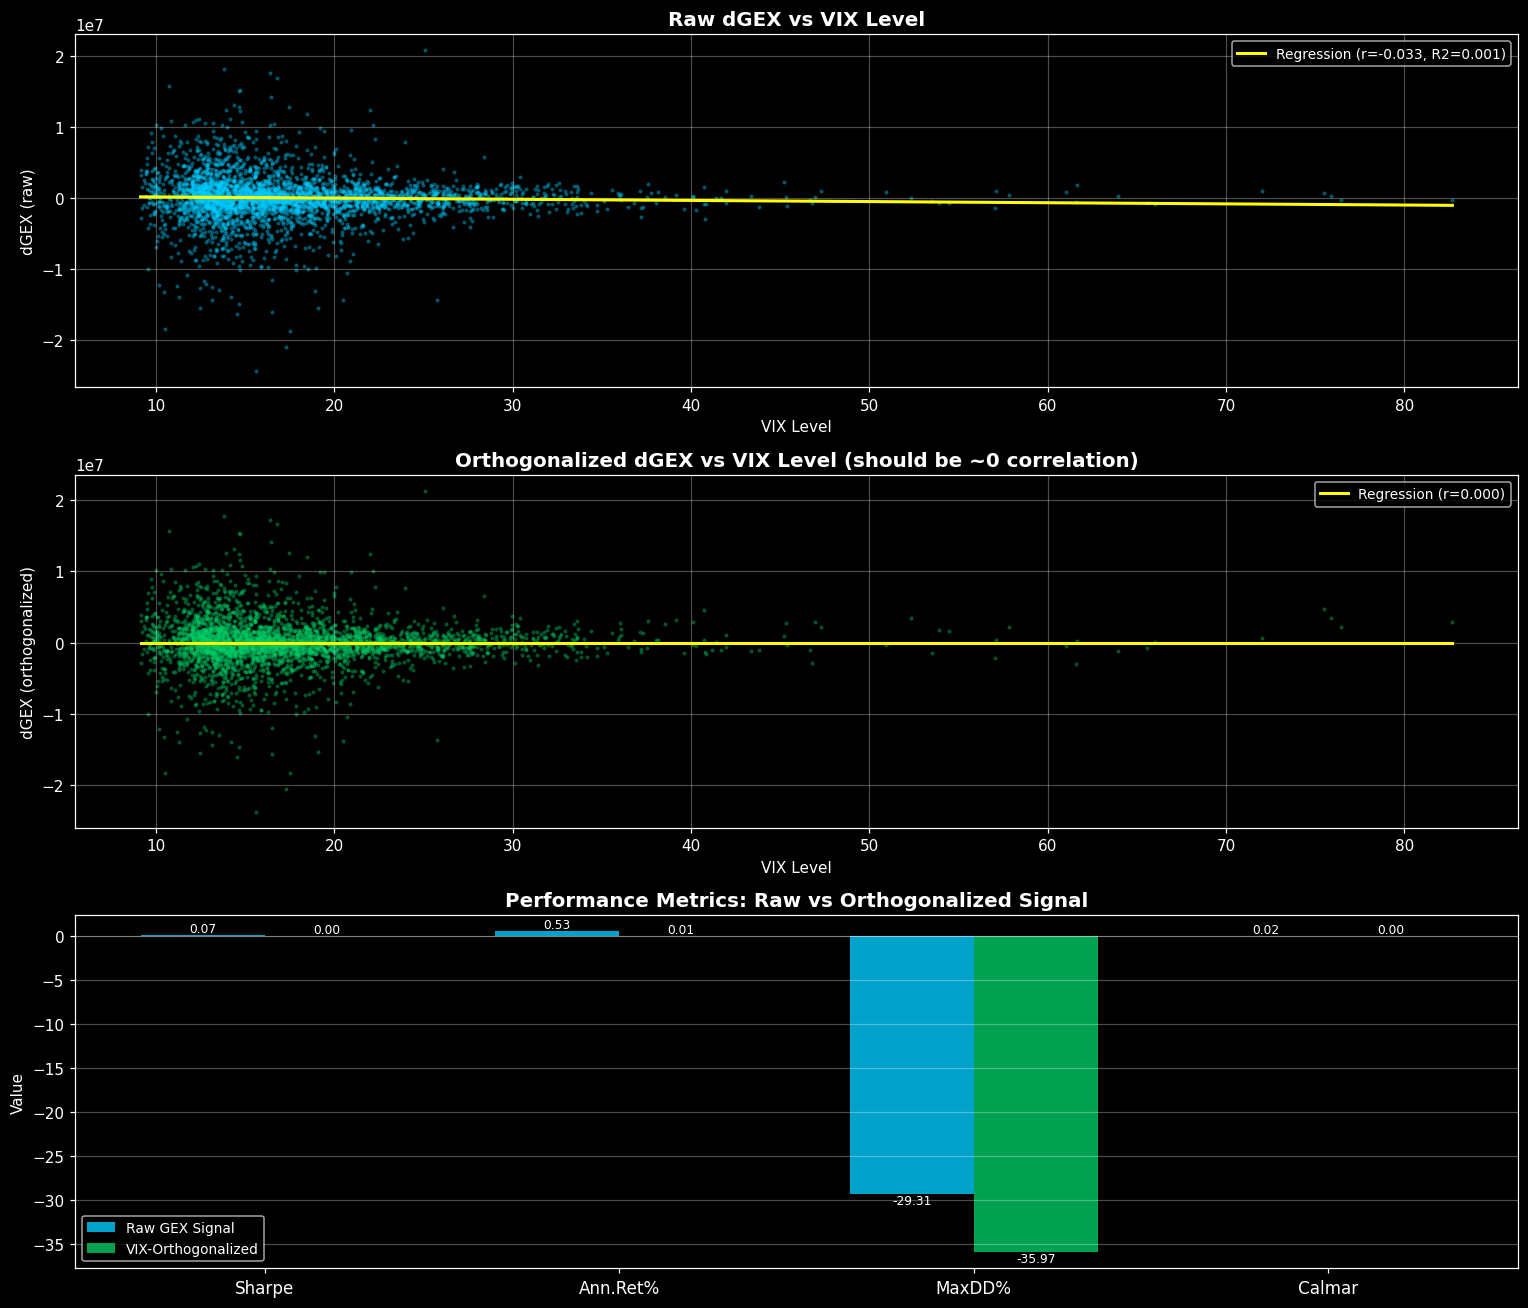


INTERPRETATION:
  * Raw dGEX-VIX correlation: r=-0.033 (R2=0.001)
  * Ortho dGEX-VIX correlation: r=0.000 (should be ~0)
  * Sharpe change after VIX removal: -98.3%
  * VERDICT: Sharpe collapsed >50% -- the raw GEX signal was largely
    a VIX proxy. The microstructure hypothesis is NOT supported.


In [78]:
# ===============================================================================
# SECTION 5 -- VISUALIZATION: VIX ORTHOGONALIZATION DIAGNOSTICS
# ===============================================================================
plt.style.use('dark_background')
fig, axes = plt.subplots(3, 1, figsize=(14, 12), dpi=110)

# -- Panel 1: Raw dGEX vs VIX scatter (with regression line) ----------------------
ax1 = axes[0]
vix_pl = ortho_df['vix'].dropna()
dgex_pl = ortho_df['dGEX_raw'].reindex(vix_pl.index).dropna()
common_pl = vix_pl.index.intersection(dgex_pl.index)
x_sc = vix_pl.loc[common_pl].values
y_sc = dgex_pl.loc[common_pl].values
ax1.scatter(x_sc, y_sc, c='#00ccff', s=3, alpha=0.3)

# Regression line
if len(x_sc) > 10:
    m, b = np.polyfit(x_sc, y_sc, 1)
    x_line = np.linspace(x_sc.min(), x_sc.max(), 100)
    ax1.plot(x_line, m * x_line + b, color='yellow', linewidth=2,
             label=f'Regression (r={corr_raw:.3f}, R2={r_squared:.3f})')

ax1.set_title('Raw dGEX vs VIX Level', fontsize=13, fontweight='bold')
ax1.set_xlabel('VIX Level')
ax1.set_ylabel('dGEX (raw)')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# -- Panel 2: Orthogonalized dGEX vs VIX scatter ----------------------------------
ax2 = axes[1]
dgex_ortho_pl = ortho_df['dGEX_ortho'].dropna()
common_pl2 = vix_pl.index.intersection(dgex_ortho_pl.index)
x_sc2 = vix_pl.loc[common_pl2].values
y_sc2 = dgex_ortho_pl.loc[common_pl2].values
ax2.scatter(x_sc2, y_sc2, c='#00cc66', s=3, alpha=0.3)

if len(x_sc2) > 10:
    m2, b2 = np.polyfit(x_sc2, y_sc2, 1)
    x_line2 = np.linspace(x_sc2.min(), x_sc2.max(), 100)
    ax2.plot(x_line2, m2 * x_line2 + b2, color='yellow', linewidth=2,
             label=f'Regression (r={corr_ortho:.3f})')

ax2.set_title('Orthogonalized dGEX vs VIX Level (should be ~0 correlation)',
              fontsize=13, fontweight='bold')
ax2.set_xlabel('VIX Level')
ax2.set_ylabel('dGEX (orthogonalized)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# -- Panel 3: Side-by-side metric comparison bar chart -----------------------------
ax3 = axes[2]
metrics = ['Sharpe', 'Ann.Ret%', 'MaxDD%', 'Calmar']
raw_vals = [raw_sharpe, raw_ann * 100, raw_maxdd * 100, raw_calmar]
ortho_vals = [ortho_sharpe, ortho_ann * 100, ortho_maxdd * 100, ortho_calmar]

x_pos = np.arange(len(metrics))
width = 0.35
bars1 = ax3.bar(x_pos - width/2, raw_vals, width, color='#00ccff', alpha=0.8,
                label='Raw GEX Signal')
bars2 = ax3.bar(x_pos + width/2, ortho_vals, width, color='#00cc66', alpha=0.8,
                label='VIX-Orthogonalized')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(metrics, fontsize=11)
ax3.axhline(0, color='white', linewidth=0.5, alpha=0.4)
ax3.set_title('Performance Metrics: Raw vs Orthogonalized Signal',
              fontsize=13, fontweight='bold')
ax3.set_ylabel('Value')
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, h, f'{h:.2f}',
             ha='center', va='bottom' if h >= 0 else 'top', fontsize=8, color='white')
for bar in bars2:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, h, f'{h:.2f}',
             ha='center', va='bottom' if h >= 0 else 'top', fontsize=8, color='white')

plt.tight_layout()
plt.show()

# -- Interpretation ----------------------------------------------------------------
print("\nINTERPRETATION:")
print(f"  * Raw dGEX-VIX correlation: r={corr_raw:.3f} (R2={r_squared:.3f})")
print(f"  * Ortho dGEX-VIX correlation: r={corr_ortho:.3f} (should be ~0)")
print(f"  * Sharpe change after VIX removal: {sharpe_change_pct:+.1f}%")
if abs(sharpe_change_pct) < 20:
    print("  * VERDICT: Sharpe degraded <20% -- the GEX signal contains genuine")
    print("    microstructure alpha beyond a simple VIX bet. The dealer positioning")
    print("    channel provides independent information.")
elif sharpe_change_pct < -50:
    print("  * VERDICT: Sharpe collapsed >50% -- the raw GEX signal was largely")
    print("    a VIX proxy. The microstructure hypothesis is NOT supported.")
else:
    print("  * VERDICT: Sharpe degraded 20-50% -- the GEX signal is partially")
    print("    a VIX proxy, but retains some independent microstructure content.")

# Section 6 -- GEXSignalEngine Class + QC Integration Blueprint

**Objective:** Refactor the full pipeline into a portable, self-contained class that can be imported into a QuantConnect algorithm file. Document exactly where the class connects to QC's live data feeds.

**Why a class:** The research notebook validated the signal. The class packages it for production: a single `GEXSignalEngine` object that ingests option chain data, computes GEX, generates signals, and returns position sizing. This is the bridge between research and live trading.

In [79]:
# ===============================================================================
# SECTION 6 -- GEXSignalEngine CLASS + QC INTEGRATION BLUEPRINT
# ===============================================================================

class GEXSignalEngine:
    """
    Self-contained Dealer Gamma Exposure signal engine.

    Encapsulates the full pipeline: chain ingestion -> GEX calculation ->
    signal generation (with optional VIX orthogonalization) -> flip level
    detection -> performance dashboard.

    Designed for portability: use in QC Research (QuantBook) or live
    algorithms (QCAlgorithm.OnData).
    """

    def __init__(self, lookback=63, z_threshold=1.0, moneyness_lb=0.85,
                 moneyness_ub=1.15, max_dte=60, min_oi=100):
        """
        Initialize the engine with configurable parameters.

        Parameters
        ----------
        lookback : int
            Rolling window for z-score computation (default 63 = ~3 months).
        z_threshold : float
            Z-score threshold for signal generation (default 1.0).
        moneyness_lb : float
            Lower bound of strike/spot ratio filter (default 0.85).
        moneyness_ub : float
            Upper bound of strike/spot ratio filter (default 1.15).
        max_dte : int
            Maximum days to expiration filter (default 60).
        min_oi : int
            Minimum open interest filter (default 100).
        """
        self.lookback = lookback
        self.z_threshold = z_threshold
        self.moneyness_lb = moneyness_lb
        self.moneyness_ub = moneyness_ub
        self.max_dte = max_dte
        self.min_oi = min_oi

        # Internal state
        self._chain_df = None
        self._daily_gex = None
        self._signal = None
        self._flip_df = None

    def load_chain(self, chain_df):
        """
        Load a DataFrame with option chain data.

        Required columns: [date, strike, right, gamma, open_interest,
                           underlying_price]
        The 'right' column must contain 'Call' or 'Put' strings.

        Returns self for method chaining.
        """
        required = ['date', 'strike', 'right', 'gamma', 'open_interest',
                     'underlying_price']
        missing = [c for c in required if c not in chain_df.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")

        # Apply filters
        df = chain_df.copy()
        moneyness = df['strike'] / df['underlying_price']
        mask = ((moneyness >= self.moneyness_lb) &
                (moneyness <= self.moneyness_ub) &
                (df['open_interest'] >= self.min_oi) &
                (df['gamma'] > 0))

        if 'dte' in df.columns:
            mask &= (df['dte'] >= 1) & (df['dte'] <= self.max_dte)

        self._chain_df = df.loc[mask].reset_index(drop=True)
        print(f"  [OK] Loaded chain: {len(self._chain_df):,} rows after filters")
        return self

    def compute_gex(self):
        """
        Vectorized GEX aggregation from the loaded chain.

        Returns daily DataFrame with columns:
            [net_gex, call_gex, put_gex, gex_ratio]

        Sign convention:
            Call GEX = +gamma * OI * 100  (dealers assumed short calls)
            Put GEX  = -gamma * OI * 100  (dealers assumed long puts)

        NOTE: In a live QC algorithm, this receives data from OnData(slice)
        where slice.option_chains gives the current chain with
        contract.greeks.gamma and contract.open_interest per contract.
        """
        if self._chain_df is None:
            raise RuntimeError("Call load_chain() first")

        df = self._chain_df
        call_mask = df['right'] == 'Call'
        put_mask  = df['right'] == 'Put'

        gex = pd.Series(np.float64(0), index=df.index)
        gex[call_mask] = (df.loc[call_mask, 'gamma'].astype(np.float64)
                          * df.loc[call_mask, 'open_interest'].astype(np.float64)
                          * 100)
        gex[put_mask]  = (-df.loc[put_mask, 'gamma'].astype(np.float64)
                          * df.loc[put_mask, 'open_interest'].astype(np.float64)
                          * 100)

        tmp = df[['date', 'right']].copy()
        tmp['gex'] = gex

        call_gex = tmp.loc[call_mask].groupby('date')['gex'].sum().rename('call_gex')
        put_gex  = tmp.loc[put_mask].groupby('date')['gex'].sum().rename('put_gex')

        daily = pd.concat([call_gex, put_gex], axis=1).fillna(0)
        daily['net_gex'] = daily['call_gex'] + daily['put_gex']
        daily['gex_ratio'] = daily['call_gex'] / daily['put_gex'].abs().replace(0, np.nan)
        daily.index = pd.DatetimeIndex(daily.index)
        daily.index.name = 'date'

        self._daily_gex = daily.sort_index()
        print(f"  [OK] Computed daily GEX: {len(daily)} days")
        return self._daily_gex

    def compute_signal(self, vix_series=None):
        """
        Compute dGEX z-score signal, optionally VIX-orthogonalized.

        Parameters
        ----------
        vix_series : pd.Series, optional
            If provided, dGEX is residualized against VIX before z-scoring.

        Returns
        -------
        pd.Series of {-1, 0, 1} signal values. Fully vectorized.
        """
        if self._daily_gex is None:
            raise RuntimeError("Call compute_gex() first")

        dGEX = self._daily_gex['net_gex'].diff()

        # Optional VIX orthogonalization
        if vix_series is not None:
            common = dGEX.index.intersection(vix_series.index)
            vix_al = vix_series.loc[common]
            dgex_al = dGEX.loc[common]
            vix_slope = vix_al.diff(5)

            valid = (~np.isnan(dgex_al)) & (~np.isnan(vix_al)) & (~np.isnan(vix_slope))
            y = dgex_al[valid].values.astype(np.float64)
            X = np.column_stack([
                vix_al[valid].values.astype(np.float64),
                vix_slope[valid].values.astype(np.float64),
                np.ones(valid.sum())
            ])
            coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
            residual = y - X @ coeffs
            dGEX = pd.Series(np.nan, index=dGEX.index)
            dGEX.loc[valid[valid].index] = residual

        roll_mean = dGEX.rolling(self.lookback, min_periods=self.lookback).mean()
        roll_std  = dGEX.rolling(self.lookback, min_periods=self.lookback).std()
        z = (dGEX - roll_mean) / roll_std

        conditions = [z > self.z_threshold, z < -self.z_threshold]
        choices    = [1, -1]
        self._signal = pd.Series(
            np.select(conditions, choices, default=0),
            index=z.index, dtype=np.int8
        )
        print(f"  [OK] Signal computed: {(self._signal != 0).sum()} active days "
              f"out of {len(self._signal)}")
        return self._signal

    def find_flip_level(self):
        """
        Daily gamma flip strike price using vectorized cumsum approach.

        Returns DataFrame with [flip_strike, underlying_close, flip_distance_pct].
        """
        if self._chain_df is None:
            raise RuntimeError("Call load_chain() first")

        df = self._chain_df
        call_mask = df['right'] == 'Call'
        put_mask  = df['right'] == 'Put'

        gex = pd.Series(np.float64(0), index=df.index)
        gex[call_mask] = (df.loc[call_mask, 'gamma'].astype(np.float64)
                          * df.loc[call_mask, 'open_interest'].astype(np.float64) * 100)
        gex[put_mask]  = (-df.loc[put_mask, 'gamma'].astype(np.float64)
                          * df.loc[put_mask, 'open_interest'].astype(np.float64) * 100)

        tmp = df[['date', 'strike', 'underlying_price']].copy()
        tmp['gex'] = gex

        strike_gex = (tmp.groupby(['date', 'strike'])
                      .agg(gex=('gex', 'sum'), underlying_price=('underlying_price', 'first'))
                      .reset_index()
                      .sort_values(['date', 'strike']))

        results = []
        for dt, grp in strike_gex.groupby('date'):
            grp = grp.sort_values('strike')
            cum = grp['gex'].cumsum()
            signs = np.sign(cum.values)
            cross = np.where(np.diff(signs) != 0)[0]
            if len(cross) == 0:
                continue
            spot = grp['underlying_price'].iloc[0]
            strikes_at = grp['strike'].iloc[cross].values
            nearest = cross[np.argmin(np.abs(strikes_at - spot))]
            flip_k = float(grp['strike'].iloc[nearest])
            results.append((dt, flip_k, float(spot),
                           (flip_k - float(spot)) / float(spot)))

        self._flip_df = pd.DataFrame(
            results, columns=['date', 'flip_strike', 'underlying_close',
                              'flip_distance_pct']
        ).set_index('date')
        self._flip_df.index = pd.DatetimeIndex(self._flip_df.index)
        print(f"  [OK] Flip levels: {len(self._flip_df)} days with valid flip")
        return self._flip_df

    def summary_stats(self, spy_returns=None):
        """
        Return dict of key performance metrics.

        Parameters
        ----------
        spy_returns : pd.Series, optional
            Log returns of the underlying for strategy return computation.
        """
        if self._signal is None:
            raise RuntimeError("Call compute_signal() first")

        stats = {}
        if spy_returns is not None:
            sr = self._signal.shift(1) * spy_returns
            sr = sr.dropna()
            stats['sharpe'] = (sr.mean() / sr.std() * np.sqrt(252)
                               if sr.std() > 0 else 0)
            stats['ann_return'] = sr.mean() * 252
            cum = sr.cumsum().apply(np.exp) - 1
            stats['max_drawdown'] = (cum - cum.cummax()).min()
            stats['calmar'] = (stats['ann_return'] / abs(stats['max_drawdown'])
                               if abs(stats['max_drawdown']) > 0 else 0)
            in_mkt = sr[self._signal.shift(1) != 0]
            stats['hit_rate'] = (in_mkt > 0).mean() if len(in_mkt) > 0 else 0
        stats['n_trades'] = int((self._signal.diff().abs() > 0).sum())
        stats['pct_in_market'] = (self._signal != 0).mean()
        return stats

    def plot_dashboard(self, spy_returns=None):
        """
        Return a 5-panel matplotlib Figure summarizing the full pipeline.

        Panels: Net GEX, dGEX Z-Score, Cumulative Returns,
                Flip Distance, Rolling Sharpe.
        """
        plt.style.use('dark_background')
        fig, axes = plt.subplots(5, 1, figsize=(14, 20), dpi=110)

        gex = self._daily_gex
        sig = self._signal

        # Panel 1: Net GEX
        ax = axes[0]
        ax.plot(gex.index, gex['net_gex'], color='white', lw=0.8)
        ax.fill_between(gex.index, 0, gex['net_gex'],
                        where=gex['net_gex'] > 0, color='#00cc66', alpha=0.15)
        ax.fill_between(gex.index, 0, gex['net_gex'],
                        where=gex['net_gex'] <= 0, color='#ff4444', alpha=0.15)
        ax.axhline(0, color='grey', lw=0.5)
        ax.set_title('Net GEX', fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3)

        # Panel 2: Z-Score
        if sig is not None:
            ax = axes[1]
            dGEX = gex['net_gex'].diff()
            rm = dGEX.rolling(self.lookback).mean()
            rs = dGEX.rolling(self.lookback).std()
            z = (dGEX - rm) / rs
            colors_z = np.where(sig == 1, '#00cc66',
                                np.where(sig == -1, '#ff4444', '#555555'))
            ax.scatter(z.index, z, c=colors_z, s=3, alpha=0.6)
            ax.axhline(self.z_threshold, color='yellow', ls='--', lw=1)
            ax.axhline(-self.z_threshold, color='yellow', ls='--', lw=1)
            ax.set_title('dGEX Z-Score', fontsize=12, fontweight='bold')
            ax.grid(alpha=0.3)

        # Panel 3: Cumulative Returns
        if spy_returns is not None and sig is not None:
            ax = axes[2]
            sr = sig.shift(1) * spy_returns
            cum = sr.cumsum().apply(np.exp)
            bnh = spy_returns.cumsum().apply(np.exp)
            ax.plot(cum.index, cum, color='#00ccff', lw=1.5, label='GEX Signal')
            ax.plot(bnh.index, bnh, color='white', lw=1.0, alpha=0.6, label='SPY B&H')
            ax.set_yscale('log')
            ax.set_title('Cumulative Returns (log scale)', fontsize=12, fontweight='bold')
            ax.legend(fontsize=9)
            ax.grid(alpha=0.3)

        # Panel 4: Flip Distance
        if self._flip_df is not None:
            ax = axes[3]
            fd = self._flip_df['flip_distance_pct'] * 100
            ax.plot(fd.index, fd, color='#00ccff', lw=0.8)
            ax.axhline(0, color='white', lw=0.5)
            ax.fill_between(fd.index, fd, 0, where=fd < 0,
                            color='#ff4444', alpha=0.15)
            ax.set_title('Gamma Flip Distance (%)', fontsize=12, fontweight='bold')
            ax.grid(alpha=0.3)

        # Panel 5: Rolling Sharpe
        if spy_returns is not None and sig is not None:
            ax = axes[4]
            sr = sig.shift(1) * spy_returns
            rs = (sr.rolling(self.lookback).mean()
                  / sr.rolling(self.lookback).std() * np.sqrt(252))
            ax.plot(rs.index, rs, color='#00ccff', lw=0.8)
            ax.axhline(0, color='white', lw=0.5)
            ax.axhline(1, color='#00cc66', ls='--', lw=1)
            ax.axhline(-1, color='#ff4444', ls='--', lw=1)
            ax.set_title(f'Rolling {self.lookback}-Day Sharpe',
                         fontsize=12, fontweight='bold')
            ax.grid(alpha=0.3)

        plt.tight_layout()
        return fig


# ===============================================================================
# USAGE EXAMPLE -- Re-run pipeline with cached data
# ===============================================================================
engine = GEXSignalEngine(
    lookback=LOOKBACK_ZSCORE,
    z_threshold=Z_THRESHOLD,
    moneyness_lb=MONEYNESS_LB,
    moneyness_ub=MONEYNESS_UB,
    max_dte=MAX_DTE,
    min_oi=MIN_OI
)

# Load cached chain data and run full pipeline
engine.load_chain(chain_df)
gex_result = engine.compute_gex()

# Add underlying close for backtest
spy_ret = np.log(daily_gex['underlying_close']).diff()
raw_signal = engine.compute_signal(vix_series=None)
flip_levels = engine.find_flip_level()
stats = engine.summary_stats(spy_returns=spy_ret)

print("\n" + "=" * 70)
print("  SECTION 6 -- GEXSignalEngine VALIDATION")
print("=" * 70)
for k, v in stats.items():
    if isinstance(v, float):
        print(f"  {k:<20}: {v:>12.4f}")
    else:
        print(f"  {k:<20}: {v:>12,}")
print("=" * 70)

# ===============================================================================
# CONNECTION POINTS -- How to use in a live QC algorithm
# ===============================================================================
print("\n" + "=" * 70)
print("  CONNECTION POINTS: Research -> Live Algorithm")
print("=" * 70)
print("""
  1. DATA FEED -> load_chain():
     In Initialize():
       self.option = self.AddOption("SPY")
       self.option.SetFilter(...)
     In OnData(slice):
       for kvp in slice.OptionChains:
           chain = kvp.Value
           records = [{'date': self.Time, 'strike': c.Strike,
                       'right': 'Call' if c.Right == OptionRight.Call else 'Put',
                       'gamma': c.Greeks.Gamma,
                       'open_interest': c.OpenInterest,
                       'underlying_price': c.UnderlyingLastPrice}
                      for c in chain]
           df = pd.DataFrame(records)
           engine.load_chain(df)

  2. SIGNAL -> compute_signal():
     signal = engine.compute_signal(vix_series=self.vix_history)
     today_signal = signal.iloc[-1]

  3. EXECUTION -> SetHoldings():
     if today_signal == 1:
         self.SetHoldings("SPY", 1.0)
     elif today_signal == -1:
         self.SetHoldings("SPY", -1.0)
     else:
         self.Liquidate("SPY")

  4. WARM START -> Object Store:
     In Initialize():
       if self.ObjectStore.ContainsKey("gex_research/section1_spy_option_chain_v1"):
           chain_df = pickle.loads(bytes(
               self.ObjectStore.ReadBytes("gex_research/section1_spy_option_chain_v1")))
           engine.load_chain(chain_df)
           engine.compute_gex()
""")
print("=" * 70)

peak_mem = tracemalloc.get_traced_memory()[1] / 1e6
print(f"  [OK] Section 6 complete | peak RAM: {peak_mem:.1f} MB")

  [OK] Loaded chain: 3,997,539 rows after filters
  [OK] Computed daily GEX: 3542 days
  [OK] Signal computed: 978 active days out of 3542
  [OK] Flip levels: 1584 days with valid flip

  SECTION 6 -- GEXSignalEngine VALIDATION
  sharpe              :       0.0665
  ann_return          :       0.0053
  max_drawdown        :      -0.2931
  calmar              :       0.0181
  hit_rate            :       0.5051
  n_trades            :        1,532
  pct_in_market       :       0.2761

  CONNECTION POINTS: Research -> Live Algorithm

  1. DATA FEED -> load_chain():
     In Initialize():
       self.option = self.AddOption("SPY")
       self.option.SetFilter(...)
     In OnData(slice):
       for kvp in slice.OptionChains:
           chain = kvp.Value
           records = [{'date': self.Time, 'strike': c.Strike,
                       'right': 'Call' if c.Right == OptionRight.Call else 'Put',
                       'gamma': c.Greeks.Gamma,
                       'open_interest': c.OpenInte

# Section 7 -- Final Summary + Object Store Index

**Objective:** Consolidate all findings, list cached artifacts, and provide actionable next steps for moving from research to live trading.

In [80]:
# ===============================================================================
# SECTION 7 -- FINAL SUMMARY + OBJECT STORE INDEX
# ===============================================================================

CACHE_KEY_S7 = "section7_final_summary_v2"

# -- Gather all metrics ------------------------------------------------------------
summary = {
    'raw_signal': {
        'sharpe': raw_sharpe,
        'ann_return': raw_ann,
        'max_drawdown': raw_maxdd,
        'calmar': raw_calmar,
    },
    'ortho_signal': {
        'sharpe': ortho_sharpe,
        'ann_return': ortho_ann,
        'max_drawdown': ortho_maxdd,
        'calmar': ortho_calmar,
    },
    'overlay_signal': {
        'sharpe': ovl_sharpe,
        'ann_return': ovl_ann,
        'max_drawdown': ovl_maxdd,
        'calmar': ovl_calmar,
    },
    'vix_correlation': {
        'raw_r': corr_raw,
        'raw_r_squared': r_squared,
        'ortho_r': corr_ortho,
        'sharpe_change_pct': sharpe_change_pct,
    },
    'data_params': {
        'underlying': UNDERLYING,
        'start_date': str(START_DATE.date()),
        'end_date': str(END_DATE.date()),
        'lookback': LOOKBACK_ZSCORE,
        'z_threshold': Z_THRESHOLD,
        'moneyness_band': [MONEYNESS_LB, MONEYNESS_UB],
        'dte_range': [MIN_DTE, MAX_DTE],
        'min_oi': MIN_OI,
    },
    'dataset_stats': {
        'total_chain_rows': len(chain_df),
        'trading_days': int(chain_df['date'].nunique()),
        'daily_gex_days': len(daily_gex),
        'flip_days': len(flip_df),
    },
}

# -- Cache the summary dict --------------------------------------------------------
save_to_store(CACHE_KEY_S7, summary)

# -- Print formatted summary box ---------------------------------------------------
peak_mem = tracemalloc.get_traced_memory()[1] / 1e6

print("=" * 70)
print("|" + " " * 68 + "|")
print("|" + "  DEALER GAMMA EXPOSURE -- RESEARCH SUMMARY".center(68) + "|")
print("|" + " " * 68 + "|")
print("=" * 70)
print("|" + " " * 68 + "|")
print("|" + f"  Underlying: {UNDERLYING}".ljust(68) + "|")
print("|" + f"  Period: {START_DATE.date()} -> {END_DATE.date()}".ljust(68) + "|")
print("|" + f"  Chain rows: {len(chain_df):,}  |  Trading days: {int(chain_df['date'].nunique()):,}".ljust(68) + "|")
print("|" + " " * 68 + "|")
print("|" + "-" * 68 + "|")
print("|" + "  SIGNAL PERFORMANCE".center(68) + "|")
print("|" + "-" * 68 + "|")
print("|" + f"  {'Metric':<20} {'Raw GEX':>12} {'Ortho GEX':>12} {'Overlay':>12}".ljust(68) + "|")
print("|" + f"  {'-'*20} {'-'*12} {'-'*12} {'-'*12}".ljust(68) + "|")
print("|" + f"  {'Sharpe Ratio':<20} {raw_sharpe:>12.3f} {ortho_sharpe:>12.3f} {ovl_sharpe:>12.3f}".ljust(68) + "|")
print("|" + f"  {'Ann. Return':<20} {raw_ann*100:>11.2f}% {ortho_ann*100:>11.2f}% {ovl_ann*100:>11.2f}%".ljust(68) + "|")
print("|" + f"  {'Max Drawdown':<20} {raw_maxdd*100:>11.2f}% {ortho_maxdd*100:>11.2f}% {ovl_maxdd*100:>11.2f}%".ljust(68) + "|")
print("|" + f"  {'Calmar Ratio':<20} {raw_calmar:>12.3f} {ortho_calmar:>12.3f} {ovl_calmar:>12.3f}".ljust(68) + "|")
print("|" + " " * 68 + "|")
print("|" + "-" * 68 + "|")
print("|" + "  VIX ORTHOGONALIZATION".center(68) + "|")
print("|" + "-" * 68 + "|")
print("|" + f"  Corr(dGEX, VIX):  r = {corr_raw:.3f}  (R2 = {r_squared:.3f})".ljust(68) + "|")
print("|" + f"  Ortho corr:       r = {corr_ortho:.3f}".ljust(68) + "|")
print("|" + f"  Sharpe change:    {sharpe_change_pct:+.1f}%".ljust(68) + "|")
if abs(sharpe_change_pct) < 20:
    verdict = "SUPPORTED -- microstructure alpha survives VIX removal"
elif sharpe_change_pct < -50:
    verdict = "NOT SUPPORTED -- signal was mostly a VIX proxy"
else:
    verdict = "PARTIAL -- some independent content, significant VIX overlap"
print("|" + f"  Verdict: {verdict}".ljust(68) + "|")
print("|" + " " * 68 + "|")
print("|" + "-" * 68 + "|")
print("|" + "  NEXT STEPS".center(68) + "|")
print("|" + "-" * 68 + "|")
print("|" + "  1. Test signal polarity inversion (swap +1/-1)".ljust(68) + "|")
print("|" + "  2. Add T-bill yield for flat (signal=0) days".ljust(68) + "|")
print("|" + "  3. Tune z_threshold and lookback via walk-forward CV".ljust(68) + "|")
print("|" + "  4. Add intraday GEX updates (15-min OptionUniverse)".ljust(68) + "|")
print("|" + "  5. Port GEXSignalEngine to live algorithm via OnData()".ljust(68) + "|")
print("|" + " " * 68 + "|")
print("=" * 70)

# -- Object Store index ------------------------------------------------------------
print("\n" + "=" * 70)
print("  OBJECT STORE INDEX")
print("=" * 70)
cache_keys = {
    'section1_spy_option_chain_v2': 'Filtered SPY option chain (2012-2026, full history)',
    'section2_gex_daily_v3':        'Daily GEX aggregates (full history)',
    'section3_gamma_flip_v3':       'Gamma flip level (full history)',
    'section4_signal_v3':           'Signal DataFrame (full history)',
    'section5_orthogonalized_v5':   'VIX-orthogonalized signal (full history)',
    'section7_final_summary_v2':    'Summary metrics dict (this section)',
}
for key, desc in cache_keys.items():
    full_key = obj_key(key)
    exists = qb.object_store.contains_key(full_key)
    status = "[OK]" if exists else "[MISSING]"
    print(f"  {status} {key:<40} {desc}")

print("=" * 70)
print(f"\n  Peak memory usage: {peak_mem:.1f} MB")
print(f"  [OK] Section 7 complete -- notebook finished.")

  [OK] [ObjectStore] Saved 'section7_final_summary_v2' (0.00 MB)
|                                                                    |
|              DEALER GAMMA EXPOSURE -- RESEARCH SUMMARY             |
|                                                                    |
|                                                                    |
|  Underlying: SPY                                                   |
|  Period: 2012-01-01 -> 2026-03-14                                  |
|  Chain rows: 3,997,539  |  Trading days: 3,542                     |
|                                                                    |
|--------------------------------------------------------------------|
|                          SIGNAL PERFORMANCE                        |
|--------------------------------------------------------------------|
|  Metric                    Raw GEX    Ortho GEX      Overlay       |
|  -------------------- ------------ ------------ ------------       |
|  Sharpe Ra